# SEASON 2024-2025 Football Analytics
## Match Calendar and Team Workload Analysis

This notebook analyzes the 2024-2025 season match fixtures, fixture distribution, and team workload across different competitions (Premier League, Champions League, FA Cup, EFL Cup).

**Objective**: 
- Create a comprehensive match calendar with all relevant match information
- Analyze fixture distribution and congestion patterns
- Compare team workloads across competitions

## PROJECT OVERVIEW

**Research Question**: How does fixture congestion affect competitive performance in Premier League clubs competing in Europe?

**Dataset**: 2024-25 Season - 4 Elite Teams (Arsenal, Aston Villa, Liverpool, Manchester City)

**Scope**: ~220 team-match records across all competitions (PL, Champions League, FA Cup, EFL Cup)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
import glob
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## PART 1: SETUP & DATA FOUNDATION

### 1.1 Team Color Palettes

Official club colors for consistent visualization across all analyses.

In [6]:
# Define team color palettes based on official club colors
team_colors = {
    'Arsenal': {
        'primary': '#EF0107',      # Arsenal red
        'secondary': '#023474',    # Arsenal navy / blue
        'name': 'Arsenal Red & Navy'
    },
    'Manchester City': {
        'primary': '#6CABDD',      # Man City sky blue
        'secondary': '#FFFFFF',    # White
        'name': 'Man City Sky Blue & White'
    },
    'Liverpool': {
        'primary': '#C8102E',      # Liverpool red
        'secondary': '#FFFFFF',    # White
        'name': 'Liverpool Red & White'
    },
    'Aston Villa': {
        'primary': '#670E36',      # Aston Villa claret
        'secondary': '#95BFE5',    # Aston Villa light blue
        'name': 'Aston Villa Claret & Blue'
    }
}

### 1.2 Data Loading & Standardization

Load all match data from four teams and create a unified match calendar with standardized columns for consistent analysis.

In [7]:
# Define the data directory
data_dir = Path('/home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/Data/SEASON_2024_2025')

# Define teams and their corresponding directories
teams_info = {
    'Arsenal': 'arsenal_2024_2025',
    'Aston Villa': 'aston_villa_2024_2025',
    'Liverpool': 'liverpool_2024_2025',
    'Manchester City': 'manchester_city_2024_2025'
}

# Load all match data
all_matches = []

for team_name, team_dir in teams_info.items():
    matches_file = data_dir / team_dir / f'{team_dir}_matches_all.csv'
    
    if matches_file.exists():
        df = pd.read_csv(matches_file)
        df['team'] = team_name
        all_matches.append(df)
        print(f"✓ Loaded {team_name}: {len(df)} matches")
    else:
        print(f"✗ File not found: {matches_file}")

# Combine all matches into a single dataframe
matches_df = pd.concat(all_matches, ignore_index=True)
print(f"\n✓ Total matches loaded: {len(matches_df)}")
print(f"✓ Teams included: {matches_df['team'].unique().tolist()}")

✓ Loaded Arsenal: 58 matches
✓ Loaded Aston Villa: 57 matches
✓ Loaded Liverpool: 56 matches
✓ Loaded Manchester City: 57 matches

✓ Total matches loaded: 228
✓ Teams included: ['Arsenal', 'Aston Villa', 'Liverpool', 'Manchester City']


In [8]:
# Display the raw data structure
print("Raw data columns:")
print(matches_df.columns.tolist())
print("\nFirst few rows:")
matches_df.head()

Raw data columns:
['Date', 'start_time', 'Competition', 'Round', 'Day', 'Venue', 'Result', 'goals_for', 'goals_against', 'Opponent', 'possession', 'attendance', 'captain', 'formation', 'opp_formation', 'referee', 'Match_Report_URL', 'Match_Report', 'notes', 'team']

First few rows:


,Date,start_time,Competition,Round,Day,Venue,Result,goals_for,goals_against,Opponent,possession,attendance,captain,formation,opp_formation,referee,Match_Report_URL,Match_Report,notes,team
0,2024-08-17,15:00(16:00),Premier League,Matchweek 1,Sat,Home,W,2,0,Wolves,53.0,"60,261",Martin Ødegaard,4-3-3,4-2-3-1,Jarred Gillett,https://fbref.com/en/matches/c0e3342a/Arsenal-...,Match Report,NaN,Arsenal
1,2024-08-24,17:30(18:30),Premier League,Matchweek 2,Sat,Away,W,2,0,Aston Villa,61.0,"41,587",Martin Ødegaard,4-3-3,4-4-2,Michael Oliver,https://fbref.com/en/matches/4692171a/Aston-Vi...,Match Report,NaN,Arsenal
2,2024-08-31,12:30(13:30),Premier League,Matchweek 3,Sat,Home,D,1,1,Brighton,36.0,"60,326",Martin Ødegaard,4-3-3,4-2-3-1,Chris Kavanagh,https://fbref.com/en/matches/a843d023/Arsenal-...,Match Report,NaN,Arsenal
3,2024-09-15,14:00(15:00),Premier League,Matchweek 4,Sun,Away,W,1,0,Tottenham Hotspur,36.0,"61,645",Jorginho,4-3-3,4-3-3,Jarred Gillett,https://fbref.com/en/matches/17774a57/North-Lo...,Match Report,NaN,Arsenal
4,2024-09-19,21:00,Champions Lg,League phase,Thu,Away,D,0,0,itAtalanta,46.0,"22,858",Gabriel Jesus,4-3-3,3-4-3,Clément Turpin,https://fbref.com/en/matches/108b9e41/Atalanta...,Match Report,NaN,Arsenal


In [9]:
# Process and standardize the match calendar
# Create the match calendar with required columns

def process_match_calendar(df):
    """
    Process raw match data into standardized format
    """
    calendar = pd.DataFrame()
    
    # Basic info
    calendar['team'] = df['team']
    calendar['date'] = pd.to_datetime(df['Date'])
    calendar['competition'] = df['Competition']
    calendar['opponent'] = df['Opponent']
    
    # Home/Away determination
    calendar['home_away'] = df['Venue']
    
    # Goals
    calendar['goals_for'] = df['goals_for']
    calendar['goals_against'] = df['goals_against']
    
    # Result
    calendar['result'] = df['Result']
    
    # Points calculation (W=3, D=1, L=0)
    calendar['points'] = calendar['result'].map({'W': 3, 'D': 1, 'L': 0})
    
    # Additional metrics from the data
    calendar['possession'] = df['possession'].astype(str)
    calendar['attendance'] = df['attendance'].astype(str)
    calendar['formation'] = df['formation']
    calendar['opp_formation'] = df['opp_formation']
    calendar['round'] = df['Round']
    calendar['day'] = df['Day']
    calendar['captain'] = df['captain']
    calendar['match_report_url'] = df['Match_Report_URL']
    
    # Note: Starting XI, minutes_played, xG, xGA not in raw data - will be added from player stats if available
    calendar['starting_XI'] = None  # Placeholder
    calendar['minutes_played'] = None  # Placeholder
    calendar['xG'] = None  # Placeholder
    calendar['xGA'] = None  # Placeholder
    
    return calendar

# Create the standardized match calendar
match_calendar = process_match_calendar(matches_df)

# Sort by team and date
match_calendar = match_calendar.sort_values(['team', 'date']).reset_index(drop=True)

print("Match Calendar Structure:")
print(match_calendar.info())
print("\n" + "="*80)
print("First 10 matches:")
print(match_calendar[['team', 'date', 'competition', 'opponent', 'home_away', 'goals_for', 
                       'goals_against', 'result', 'points']].head(10))

Match Calendar Structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   team              228 non-null    object        
 1   date              228 non-null    datetime64[ns]
 2   competition       228 non-null    object        
 3   opponent          228 non-null    object        
 4   home_away         228 non-null    object        
 5   goals_for         228 non-null    object        
 6   goals_against     228 non-null    object        
 7   result            228 non-null    object        
 8   points            228 non-null    int64         
 9   possession        228 non-null    object        
 10  attendance        228 non-null    object        
 11  formation         228 non-null    object        
 12  opp_formation     228 non-null    object        
 13  round             228 non-null    object        
 14  

### 1.3 Temporal Analysis: Timeline & Distribution

Analyze match distribution across the season to identify fixture density patterns and congestion periods.

In [10]:
# 3.1 Total matches per team
matches_per_team = match_calendar.groupby('team').size().reset_index(name='Total Matches')
matches_per_team = matches_per_team.sort_values('Total Matches', ascending=False)

print("TOTAL MATCHES PER TEAM")
print("="*50)
print(matches_per_team.to_string(index=False))
print(f"\nGrand Total: {matches_per_team['Total Matches'].sum()} matches")

print("\n" + "="*80 + "\n")

# 3.2 Matches per competition
competition_stats = match_calendar.groupby('competition').size().reset_index(name='Total Matches')
competition_stats = competition_stats.sort_values('Total Matches', ascending=False)

print("TOTAL MATCHES PER COMPETITION (All Teams)")
print("="*50)
print(competition_stats.to_string(index=False))

print("\n" + "="*80 + "\n")

# 3.3 Matches by team and competition (Cross-tabulation)
team_competition = pd.crosstab(match_calendar['team'], match_calendar['competition'], margins=True)

print("MATCHES BY TEAM AND COMPETITION")
print("="*80)
print(team_competition)

TOTAL MATCHES PER TEAM
           team  Total Matches
        Arsenal             58
    Aston Villa             57
Manchester City             57
      Liverpool             56

Grand Total: 228 matches


TOTAL MATCHES PER COMPETITION (All Teams)
        competition  Total Matches
     Premier League            152
       Champions Lg             46
            EFL Cup             15
             FA Cup             14
FA Community Shield              1


MATCHES BY TEAM AND COMPETITION
competition      Champions Lg  EFL Cup  FA Community Shield  FA Cup  \
team                                                                  
Arsenal                    14        5                    0       1   
Aston Villa                12        2                    0       5   
Liverpool                  10        6                    0       2   
Manchester City            10        2                    1       6   
All                        46       15                    1      14   

competitio

### 1.4 Workload Summary: Matches by Competition

Create pivot tables and visualizations showing each team's match count across competitions, revealing differential European participation and total fixture burden.

SEASON 2024-2025 - DATE RANGE


Start Date: 2024-08-10
End Date:   2025-05-25
Total Days: 288 days
Duration:   41.1 weeks


MATCHES DISTRIBUTION BY MONTH (SEASON 2024-2025)
  month  Matches
2024-08       12
2024-09       21
2024-10       24
2024-11       21
2024-12       31
2025-01       31
2025-02       27
2025-03       16
2025-04       27
2025-05       18


MATCHES BY MONTH AND TEAM (SEASON 2024-2025)
team     Arsenal  Aston Villa  Liverpool  Manchester City  All
date                                                          
2024-08        3            3          2                4   12
2024-09        5            5          6                5   21
2024-10        6            6          6                6   24
2024-11        6            5          5                5   21
2024-12        7            8          8                8   31
2025-01        9            7          8                7   31
2025-02        5            7          8                7   27
2025-03        4            4          4                4

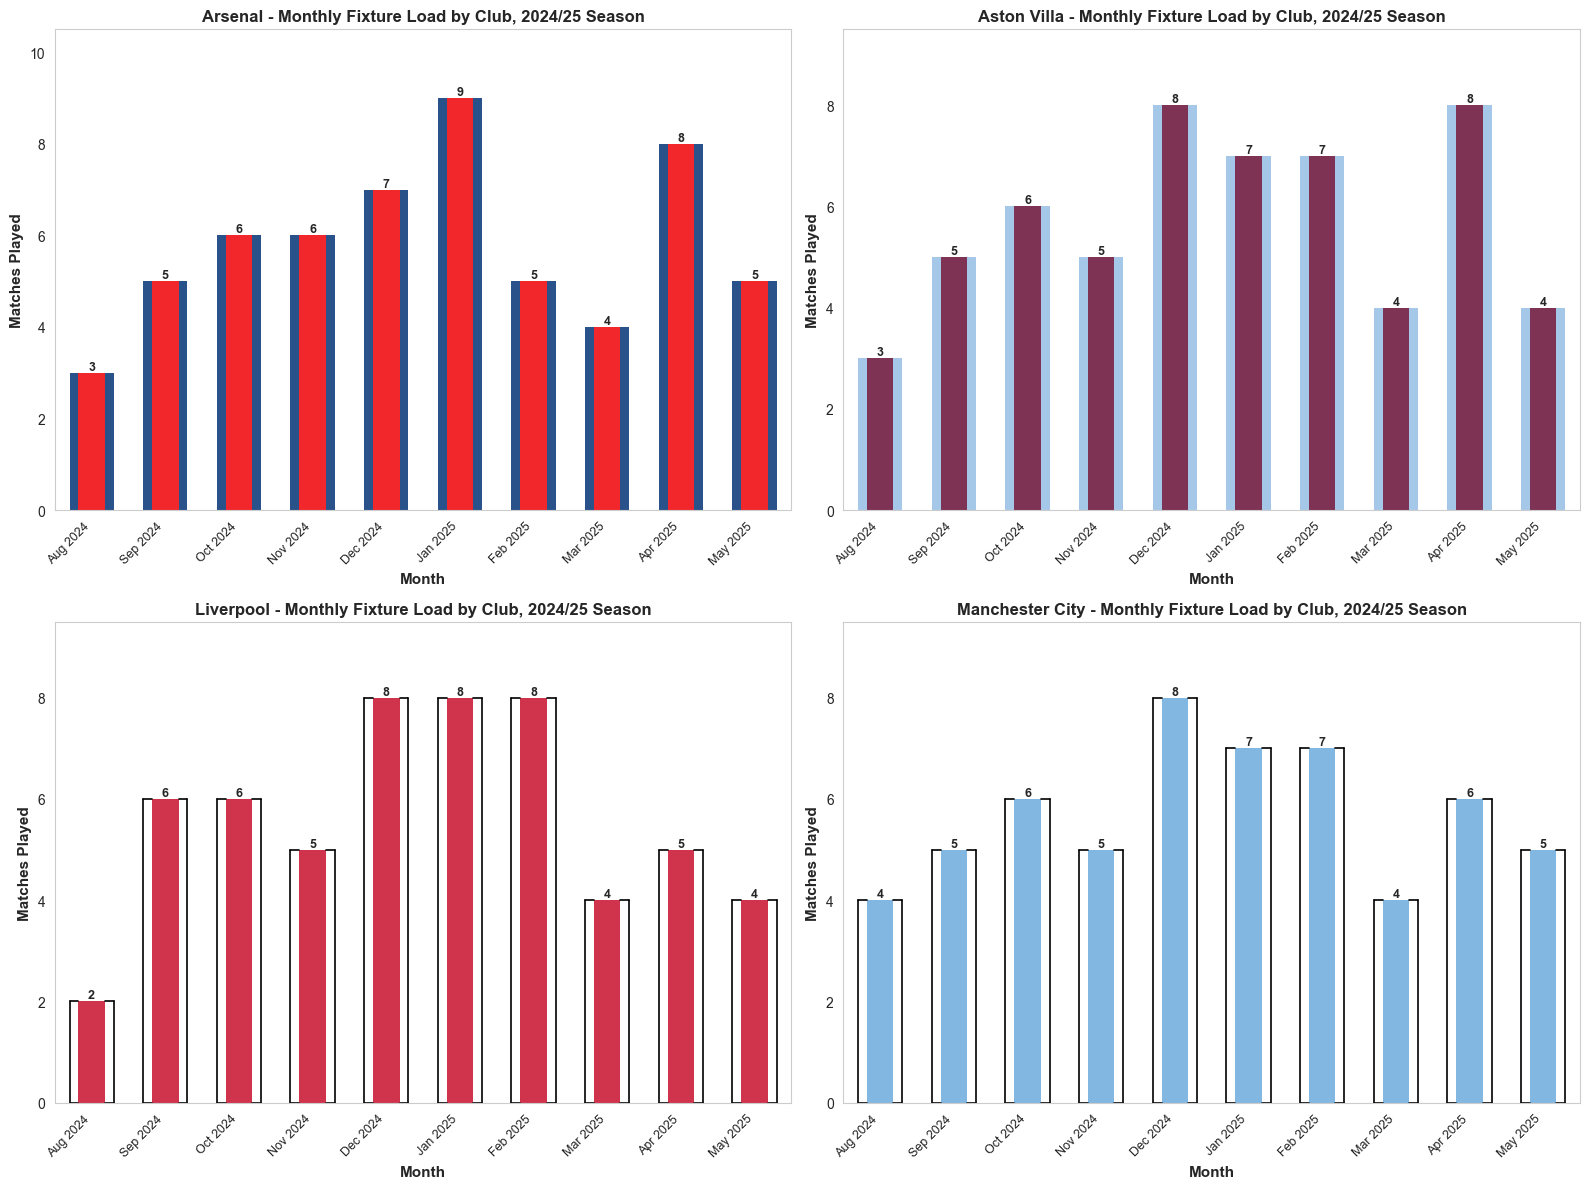

✓ Vertical Stripes visualization displayed: Center stripe primary, lateral stripes secondary

VISUALIZATION COMPLETE
VERTICAL STRIPES: Center stripe primary (60%), lateral stripes secondary (20% each)
Liverpool & Manchester City: Thin black outline borders on outer edges only


In [ ]:
# 4.1 Date range of the season
print("SEASON 2024-2025 - DATE RANGE")
print("="*50)
print(f"Start Date: {match_calendar['date'].min().date()}")
print(f"End Date:   {match_calendar['date'].max().date()}")
print(f"Total Days: {(match_calendar['date'].max() - match_calendar['date'].min()).days} days")
print(f"Duration:   {(match_calendar['date'].max() - match_calendar['date'].min()).days / 7:.1f} weeks")

print("\n" + "="*80 + "\n")

# 4.2 Matches by month
match_calendar['month'] = match_calendar['date'].dt.to_period('M')
matches_by_month = match_calendar.groupby('month').size().reset_index(name='Matches')

print("MATCHES DISTRIBUTION BY MONTH (2024-2025 SEASON)")
print("="*50)
print(matches_by_month.to_string(index=False))

print("\n" + "="*80 + "\n")

# 4.3 Matches by month and team
matches_month_team = pd.crosstab(match_calendar['date'].dt.to_period('M'), 
                                  match_calendar['team'], 
                                  margins=True)

print("MATCHES BY MONTH AND TEAM (2024-2025 SEASON)")
print("="*80)
print(matches_month_team)

print("\n" + "="*80 + "\n")

# 4.4 Mini bar charts - One per team with multiple color options
matches_month_team_clean = pd.crosstab(match_calendar['date'].dt.to_period('M'), 
                                       match_calendar['team'])
month_labels = [period.strftime('%b %Y') for period in matches_month_team_clean.index]

teams_sorted = sorted(match_calendar['team'].unique())

# Import for color interpolation (used in Option 2)
from matplotlib.colors import to_rgb

def interpolate_color(color1, color2, factor):
    """Interpolate between two hex colors"""
    c1 = to_rgb(color1)
    c2 = to_rgb(color2)
    result = tuple(c1[i] + (c2[i] - c1[i]) * factor for i in range(3))
    return result

# ============================================================================
# OPTION 2: VERTICAL STRIPES (center primary, sides secondary)
# ============================================================================
print("DISPLAYING VERTICAL STRIPES VISUALIZATION")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, team in enumerate(teams_sorted):
    ax = axes[idx]
    values = matches_month_team_clean[team].values
    x = np.arange(len(month_labels))
    
    primary_hex = team_colors[team]['primary']
    secondary_hex = team_colors[team]['secondary']
    
    # Use secondary color for outline, or dark gray for Liverpool/Manchester City
    if team in ['Liverpool', 'Manchester City']:
        outline_color = '#111111'  # Dark gray/black
    else:
        outline_color = secondary_hex  # Team's secondary color
    
    bar_width = 0.6
    
    # Create bars with vertical stripes
    for i, (xi, height) in enumerate(zip(x, values)):
        # Left stripe (secondary color) - 20% width
        ax.add_patch(plt.Rectangle((xi - bar_width/2, 0), bar_width * 0.2, height, 
                                   facecolor=secondary_hex, edgecolor='none', alpha=0.85))
        # Center stripe (primary color) - 60% width with no outline
        ax.add_patch(plt.Rectangle((xi - bar_width * 0.3, 0), bar_width * 0.6, height, 
                                   facecolor=primary_hex, edgecolor='none', linewidth=0, alpha=0.85))
        # Right stripe (secondary color) - 20% width
        ax.add_patch(plt.Rectangle((xi + bar_width * 0.3, 0), bar_width * 0.2, height, 
                                   facecolor=secondary_hex, edgecolor='none', alpha=0.85))
        
        # Add black borders ONLY for Liverpool and Manchester City (thin lines, outer edges only)
        if team in ['Liverpool', 'Manchester City']:
            # Left stripe: left edge, top edge, bottom edge (NOT right edge that touches center)
            left_x = xi - bar_width/2
            right_x = xi - bar_width * 0.3
            ax.plot([left_x, left_x], [0, height], color='#000000', linewidth=1.2)  # Left edge
            ax.plot([left_x, right_x], [height, height], color='#000000', linewidth=1.2)  # Top edge
            ax.plot([left_x, right_x], [0, 0], color='#000000', linewidth=1.2)  # Bottom edge
            
            # Right stripe: right edge, top edge, bottom edge (NOT left edge that touches center)
            left_x = xi + bar_width * 0.3
            right_x = xi + bar_width/2
            ax.plot([right_x, right_x], [0, height], color='#000000', linewidth=1.2)  # Right edge
            ax.plot([left_x, right_x], [height, height], color='#000000', linewidth=1.2)  # Top edge
            ax.plot([left_x, right_x], [0, 0], color='#000000', linewidth=1.2)  # Bottom edge
        
        # Add value label
        ax.text(xi, height, f'{int(height)}', ha='center', va='bottom', 
               fontweight='bold', fontsize=9)
    
    ax.set_xlabel('Month', fontsize=11, fontweight='bold')
    ax.set_ylabel('Matches Played', fontsize=11, fontweight='bold')
    ax.set_title(f'{team} - Monthly Fixture Load by Club, 2024/25 Season', 
                fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(month_labels, rotation=45, ha='right', fontsize=9)
    ax.set_xlim(-0.5, len(month_labels) - 0.5)
    ax.set_ylim(0, values.max() + 1.5)
    ax.grid(False)

plt.tight_layout()
plt.show()
print("✓ Vertical Stripes visualization displayed: Center stripe primary, lateral stripes secondary\n")

print("="*80)
print("VISUALIZATION COMPLETE")
print("="*80)
print("VERTICAL STRIPES: Center stripe primary (60%), lateral stripes secondary (20% each)")
print("Liverpool & Manchester City: Thin black outline borders on outer edges only")
print("="*80)


## 5. Team Workload Summary Table

Create a pivot table showing each team's match count across competitions with total matches.

TEAM WORKLOAD SUMMARY - MATCHES BY COMPETITION
competition_category  Premier League  Champions League  FA Cup  EFL Cup  Community Shield  Total
team                                                                                            
Arsenal                           38                14       1        5                 0     58
Aston Villa                       38                12       5        2                 0     57
Manchester City                   38                10       6        2                 1     57
Liverpool                         38                10       2        6                 0     56

KEY STATISTICS:
Total Matches Across All Teams: 228
Average Matches per Team: 57.0
Team with Most Matches: Arsenal (58 matches)
Team with Fewest Matches: Liverpool (56 matches)


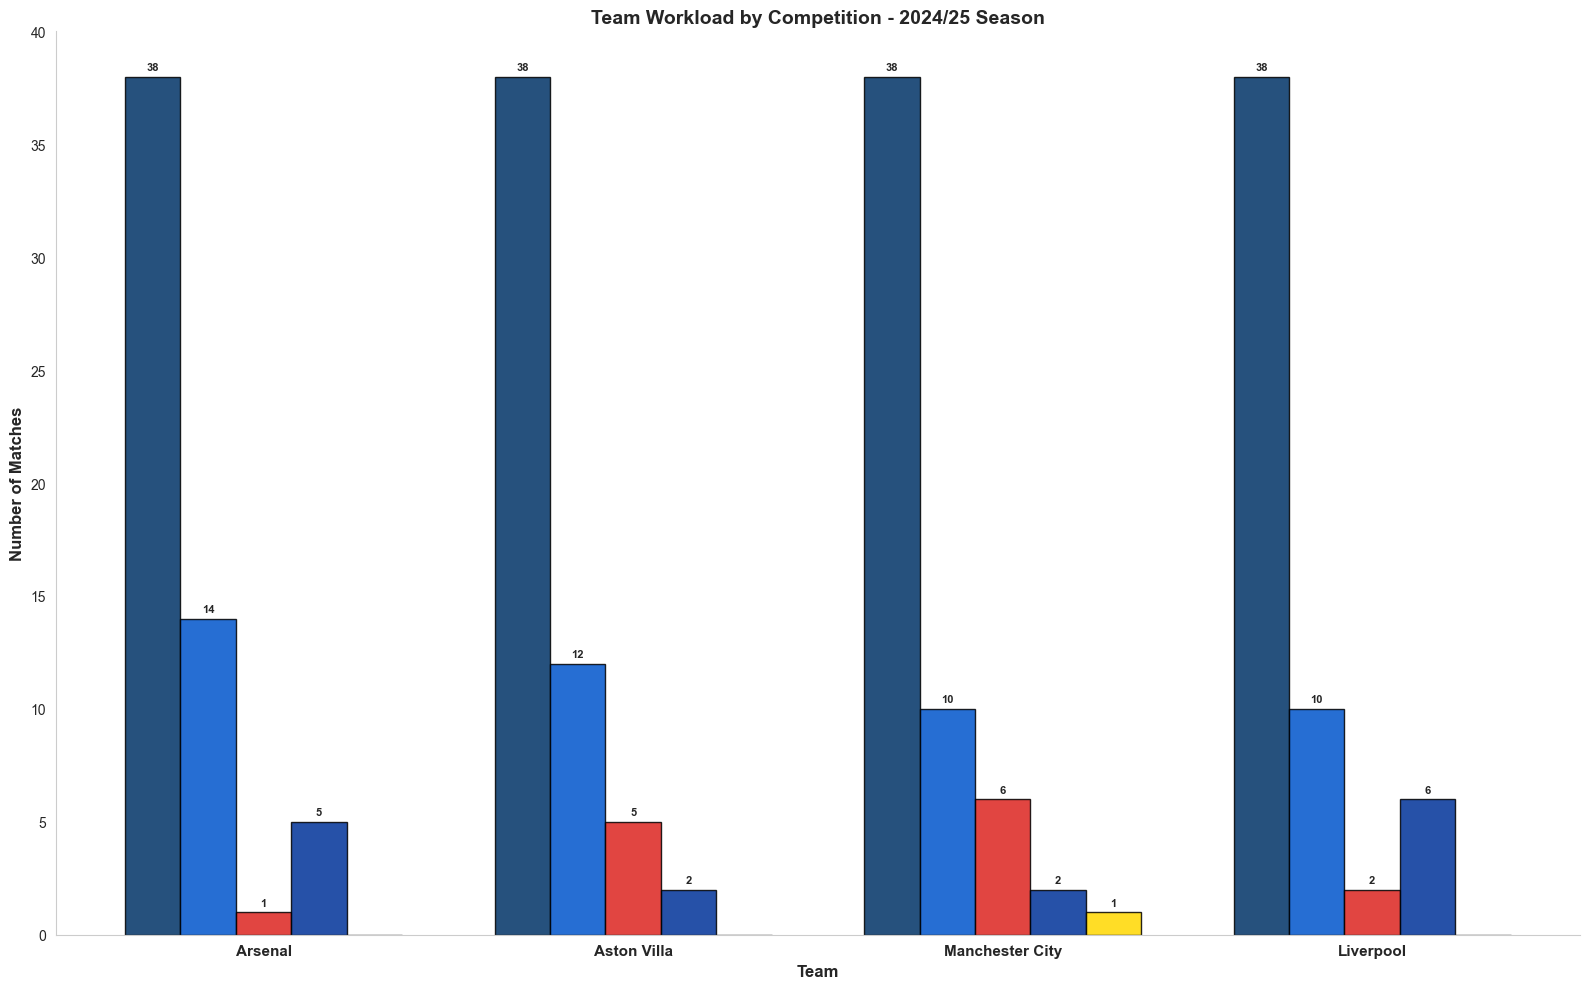


✓ Workload summary with uniform-sized competition logos (transparent background) created


In [ ]:
# 5.1 Create detailed workload summary table
# Extract primary colors for easy reference
primary_colors = {team: team_colors[team]['primary'] for team in team_colors.keys()}

# Map competitions to categories
def map_competition(comp):
    if 'Premier League' in comp:
        return 'Premier League'
    elif 'Champions' in comp:
        return 'Champions League'
    elif 'FA Cup' in comp:
        return 'FA Cup'
    elif 'EFL Cup' in comp:
        return 'EFL Cup'
    elif 'Community Shield' in comp:
        return 'Community Shield'
    else:
        return 'Other'

match_calendar['competition_category'] = match_calendar['competition'].apply(map_competition)

# Create pivot table
workload_table = pd.crosstab(match_calendar['team'], 
                             match_calendar['competition_category'], 
                             margins=False)

# Reorder columns for better readability
column_order = ['Premier League', 'Champions League', 'FA Cup', 'EFL Cup', 'Community Shield']
existing_cols = [col for col in column_order if col in workload_table.columns]
workload_table = workload_table[existing_cols]

# Add total column
workload_table['Total'] = workload_table.sum(axis=1)

# Sort by total matches descending
workload_table = workload_table.sort_values('Total', ascending=False)

print("TEAM WORKLOAD SUMMARY - MATCHES BY COMPETITION (2024-2025 SEASON)")
print("="*100)
print(workload_table.to_string())
print("="*100)

# 5.2 Summary statistics
print("\nKEY STATISTICS:")
print(f"Total Matches Across All Teams: {workload_table['Total'].sum()}")
print(f"Average Matches per Team: {workload_table['Total'].mean():.1f}")
print(f"Team with Most Matches: {workload_table['Total'].idxmax()} ({workload_table['Total'].max()} matches)")
print(f"Team with Fewest Matches: {workload_table['Total'].idxmin()} ({workload_table['Total'].min()} matches)")

# 5.3 Visualize workload with grouped bars by competition and competition logos
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Define competition colors
competition_colors_dict = {
    'Premier League': '#003366',
    'Champions League': '#0055CC',
    'FA Cup': '#DC241F',
    'EFL Cup': '#003399',
    'Community Shield': '#FFD700',
    'Other': '#CCCCCC'
}

# Logo directory path
logos_dir = Path('/home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/EDA/LOGOS')

# Map competitions to their logo filenames
competition_logo_map = {
    'Premier League': 'england_english-premier-league_128x128.football-logos.cc.png',
    'Champions League': 'tournaments_uefa-champions-league_128x128.football-logos.cc.png',
    'FA Cup': 'england_emirates-fa-cup_128x128.football-logos.cc.png',
    'EFL Cup': 'england_efl-cup_128x128.football-logos.cc.png',
    'Community Shield': 'england_fa-community-shield_128x128.football-logos.cc.png'
}

# Define zoom levels for each competition
competition_zoom = {
    'Premier League': 0.55,
    'Champions League': 0.50,
    'FA Cup': 0.40,
    'EFL Cup': 0.55,
    'Community Shield': 0.40
}

# Define vertical position offsets for each competition
competition_position = {
    'Premier League': 1.2,
    'Champions League': 2.5,
    'FA Cup': 1.8,
    'EFL Cup': 2.5,
    'Community Shield': 1.8
}

# Pre-load and resize logos to uniform size with transparent background
logo_cache = {}
LOGO_SIZE = (80, 80)  # Uniform size for all logos

for comp, filename in competition_logo_map.items():
    logo_file = logos_dir / filename
    if logo_file.exists():
        try:
            # Open image and convert to RGBA for transparent background
            img = Image.open(logo_file).convert('RGBA')
            
            # Resize image to uniform size while maintaining aspect ratio
            img.thumbnail(LOGO_SIZE, Image.LANCZOS)
            
            # Create a new transparent image with the target size
            transparent_img = Image.new('RGBA', LOGO_SIZE, (255, 255, 255, 0))
            
            # Calculate position to center the logo
            offset_x = (LOGO_SIZE[0] - img.size[0]) // 2
            offset_y = (LOGO_SIZE[1] - img.size[1]) // 2
            
            # Paste the resized logo onto the transparent background
            transparent_img.paste(img, (offset_x, offset_y), img)
            
            logo_cache[comp] = transparent_img
        except Exception as e:
            print(f"Could not load logo for {comp}: {e}")

# Create figure with grouped bar chart
fig, ax = plt.subplots(figsize=(16, 10))

# Prepare data for grouped bar chart
workload_table_sorted = workload_table.sort_values('Total', ascending=False)

# Create grouped bar chart showing each team's breakdown
x = np.arange(len(workload_table_sorted))
bar_width = 0.15
offset = -(len(existing_cols) - 1) * bar_width / 2

for comp_idx, competition in enumerate(existing_cols):
    values = workload_table_sorted[competition].values
    color = competition_colors_dict[competition]
    
    bars = ax.bar(x + offset, values, bar_width, 
           color=color, edgecolor='black', linewidth=1, alpha=0.85)
    
    # Add value labels on top of bars
    for i, value in enumerate(values):
        if value > 0:
            ax.text(x[i] + offset, value + 0.2, f'{int(value)}', 
                    ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    # Add logos on top of bars for this competition
    if competition in logo_cache:
        img = logo_cache[competition]
        zoom_level = competition_zoom.get(competition, 0.55)
        position_offset = competition_position.get(competition, 1.8)
        for i, (bar, value) in enumerate(zip(bars, values)):
            if value > 0:  # Only add logo if there's a bar
                try:
                    imagebox = OffsetImage(img, zoom=zoom_level)
                    ab = AnnotationBbox(imagebox, 
                                      (x[i] + offset, value + position_offset), 
                                      xycoords='data', frameon=False, pad=0)
                    ax.add_artist(ab)
                except:
                    pass
    
    offset += bar_width

# Create custom legend with competition colors
legend_labels = []
for competition in existing_cols:
    legend_labels.append(plt.Rectangle((0,0),1,1, fc=competition_colors_dict[competition], 
                                      edgecolor='black', linewidth=1.5, alpha=0.85,
                                      label=competition))

ax.set_xlabel('Team', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Matches', fontsize=12, fontweight='bold')
ax.set_title('Team Workload by Competition - 2024/25 Season', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(workload_table_sorted.index, rotation=0, ha='center', fontsize=11, fontweight='bold')
ax.grid(False)

# Set y-axis limit to 40 matches
ax.set_ylim(0, 40)

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\n✓ Workload summary with uniform-sized competition logos (transparent background) created")

### 1.5 Congestion Heatmap: Weekly Fixture Density

Visualize weekly match counts across the season, identifying high-congestion periods (2+ matches per week) and team-specific patterns.

MATCHES PER WEEK BY TEAM

TOP 10 MOST CONGESTED WEEKS (by total matches)
team       Arsenal  Aston Villa  Liverpool  Manchester City  Total_Matches  Avg_Per_Team
year_week                                                                               
2024-W38       2.0          2.0        2.0              2.0            8.0           2.0
2024-W48       2.0          2.0        2.0              2.0            8.0           2.0
2024-W44       2.0          2.0        2.0              2.0            8.0           2.0
2024-W43       2.0          2.0        2.0              2.0            8.0           2.0
2024-W40       2.0          2.0        2.0              2.0            8.0           2.0
2024-W39       2.0          2.0        2.0              2.0            8.0           2.0
2025-W03       2.0          2.0        2.0              2.0            8.0           2.0
2025-W05       2.0          2.0        2.0              2.0            8.0           2.0
2025-W14       2.0          2.0      

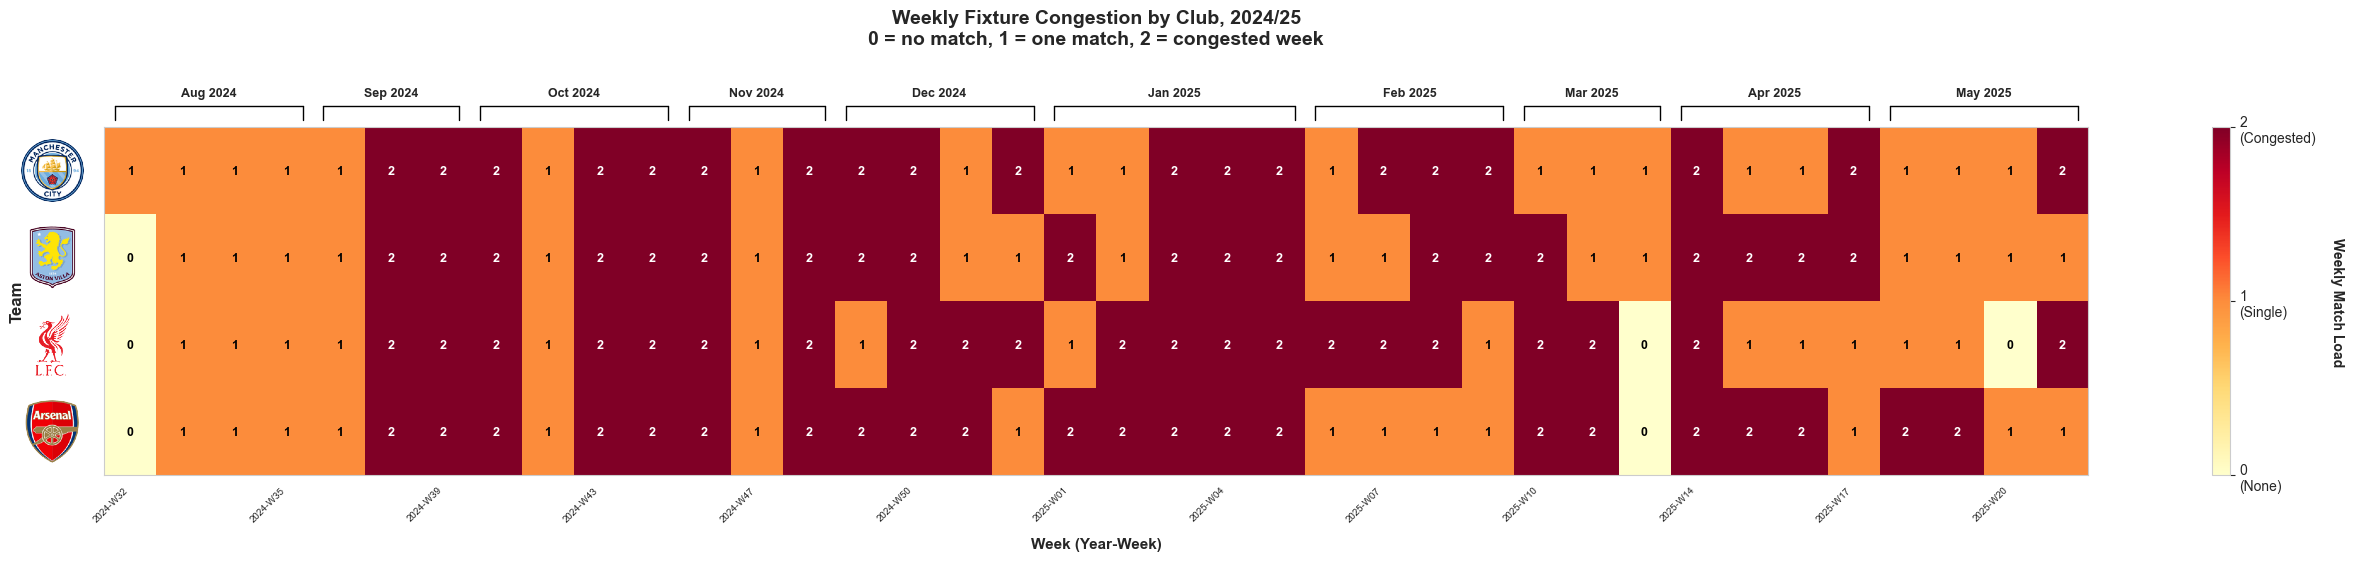

✓ Weekly congestion heatmap created (color intensity shows match load)


SUMMARY: CONGESTION PATTERNS ACROSS TEAMS

Weeks with 2+ matches for ALL teams: 12
Weeks: 2024-W38, 2024-W39, 2024-W40, 2024-W43, 2024-W44, 2024-W45, 2024-W48, 2024-W50, 2025-W03, 2025-W04, 2025-W05, 2025-W14

Weeks with 2+ matches for ANY team: 29

--------------------------------------------------------------------------------
CONGESTED WEEKS BY TEAM (2+ Matches per Week)
--------------------------------------------------------------------------------

Arsenal: 22 congested weeks
  Weeks: 2024-W38, 2024-W39, 2024-W40, 2024-W43, 2024-W44, 2024-W45, 2024-W48, 2024-W49, 2024-W50, 2024-W51, 2025-W01, 2025-W02, 2025-W03, 2025-W04, 2025-W05, 2025-W10, 2025-W11, 2025-W14, 2025-W15, 2025-W16, 2025-W18, 2025-W19

Liverpool: 21 congested weeks
  Weeks: 2024-W38, 2024-W39, 2024-W40, 2024-W43, 2024-W44, 2024-W45, 2024-W48, 2024-W50, 2024-W51, 2024-W52, 2025-W02, 2025-W03, 2025-W04, 2025-W05, 2025-W06, 2025-W07, 2025-W08, 20

In [13]:
# 6.1 Calculate matches per week for each team
match_calendar['week'] = match_calendar['date'].dt.isocalendar().week
match_calendar['year'] = match_calendar['date'].dt.isocalendar().year
match_calendar['year_week'] = match_calendar['year'].astype(str) + '-W' + match_calendar['week'].astype(str).str.zfill(2)

# Matches per week by team
matches_per_week = match_calendar.groupby(['team', 'year_week', 'week']).size().reset_index(name='matches')

print("MATCHES PER WEEK BY TEAM")
print("="*80)

# Find weeks with congestion (multiple matches per team)
congestion_analysis = matches_per_week.pivot_table(index='year_week', columns='team', values='matches', fill_value=0)

# Define team columns to correctly calculate average
team_cols = ['Arsenal', 'Aston Villa', 'Liverpool', 'Manchester City']

congestion_analysis['Total_Matches'] = congestion_analysis[team_cols].sum(axis=1)
congestion_analysis['Avg_Per_Team'] = (
    congestion_analysis['Total_Matches'] / len(team_cols)
)

# Sort by total matches
congestion_analysis = congestion_analysis.sort_values('Total_Matches', ascending=False)

print("\nTOP 10 MOST CONGESTED WEEKS (by total matches)")
print(congestion_analysis.head(10).to_string())

print("\n" + "="*80 + "\n")

# 6.2 Teams with most busy weeks (with percentage analysis)
print("WEEKS WITH 2+ MATCHES BY TEAM")
print("="*80)

busy_summary = (
    matches_per_week
    .assign(busy_week=lambda x: x['matches'] >= 2)
    .groupby('team')
    .agg(
        active_weeks=('year_week', 'count'),
        busy_weeks=('busy_week', 'sum'),
        avg_matches_per_week=('matches', 'mean'),
        max_matches_per_week=('matches', 'max')
    )
    .reset_index()
)

busy_summary['busy_week_rate'] = (
    busy_summary['busy_weeks'] / busy_summary['active_weeks'] * 100
).round(1)

busy_summary = busy_summary.sort_values('busy_weeks', ascending=False)

print(busy_summary.to_string(index=False))

print("\n" + "="*80 + "\n")

# 6.3 Average matches per week by team
avg_matches_per_week = matches_per_week.groupby('team')['matches'].agg(['mean', 'max', 'min', 'std']).round(2)
avg_matches_per_week.columns = ['Avg Matches/Week', 'Max Matches/Week', 'Min Matches/Week', 'Std Dev']

print("WEEKLY SCHEDULE INTENSITY BY TEAM")
print("="*80)
print(avg_matches_per_week.sort_values('Avg Matches/Week', ascending=False).to_string())

print("\n" + "="*80 + "\n")

# 6.4 Visualize congestion: Weekly congestion heatmap (MAIN VISUALIZATION)

# Calculate congestion threshold (average matches per week per team)
overall_avg_matches_per_week = matches_per_week['matches'].mean()
print(f"Overall Average Matches per Week: {overall_avg_matches_per_week:.2f}")
print(f"Congestion Threshold (2+ matches per week)")
print("\n" + "="*80 + "\n")

teams_sorted = sorted(match_calendar['team'].unique())
# Reorder teams by congestion frequency (most to least congested)
team_cols = ['Arsenal', 'Liverpool', 'Aston Villa', 'Manchester City']

# Prepare heatmap data - pivot table with weeks as rows, teams as columns
heatmap_data = matches_per_week.pivot_table(index='year_week', columns='team', values='matches', fill_value=0)

# Reorder columns to match our team list
heatmap_data = heatmap_data[team_cols]

# Sort by week
heatmap_data = heatmap_data.sort_index()

print("WEEKLY CONGESTION HEATMAP DATA - MATCHES PER TEAM")
print("="*80)
print(heatmap_data.to_string())
print("\n" + "="*80 + "\n")

# Create heatmap visualization - HORIZONTAL FORMAT
fig, ax = plt.subplots(figsize=(32, 6))

# Transpose heatmap data so teams are on y-axis and weeks are on x-axis
heatmap_data_transposed = heatmap_data.T

# Create heatmap using matplotlib imshow
im = ax.imshow(heatmap_data_transposed.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=2, origin='lower')

# Disable grid
ax.grid(False)

# Set ticks and labels
ax.set_xticks(np.arange(len(heatmap_data_transposed.columns)))
ax.set_yticks(np.arange(len(heatmap_data_transposed.index)))
ax.set_xticklabels(heatmap_data_transposed.columns, fontsize=8, rotation=45, ha='right')

# Load and display team logos on y-axis instead of text labels
logos_dir = Path('/home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/EDA/LOGOS')

# Map team names to logo filenames
team_logo_files = {
    'Arsenal': 'england_arsenal_128x128.football-logos.cc.png',
    'Aston Villa': 'england_aston-villa_128x128.football-logos.cc.png',
    'Liverpool': 'england_liverpool_128x128.football-logos.cc.png',
    'Manchester City': 'england_manchester-city_128x128.football-logos.cc.png'
}

# Load and cache team logos
team_logo_cache = {}
LOGO_SIZE_HEATMAP = (100, 100)

for team, filename in team_logo_files.items():
    logo_file = logos_dir / filename
    if logo_file.exists():
        try:
            # Open image and convert to RGBA for transparent background
            img = Image.open(logo_file).convert('RGBA')
            
            # Resize image to uniform size while maintaining aspect ratio
            img.thumbnail(LOGO_SIZE_HEATMAP, Image.LANCZOS)
            
            # Create a new transparent image with the target size
            transparent_img = Image.new('RGBA', LOGO_SIZE_HEATMAP, (255, 255, 255, 0))
            
            # Calculate position to center the logo
            offset_x = (LOGO_SIZE_HEATMAP[0] - img.size[0]) // 2
            offset_y = (LOGO_SIZE_HEATMAP[1] - img.size[1]) // 2
            
            # Paste the resized logo onto the transparent background
            transparent_img.paste(img, (offset_x, offset_y), img)
            
            team_logo_cache[team] = transparent_img
        except Exception as e:
            print(f"Warning: Could not load logo for {team}: {e}")

# Remove y-axis tick labels and place logos instead
ax.set_yticklabels([])

# Place team logos at y-axis positions
for idx, team in enumerate(heatmap_data_transposed.index):
    if team in team_logo_cache:
        logo_img = team_logo_cache[team]
        imagebox = OffsetImage(logo_img, zoom=0.45)
        # Position logo at left edge of plot, aligned with team row
        ab = AnnotationBbox(imagebox, (-1.5, idx), xycoords='data', 
                           frameon=False, pad=0, annotation_clip=False)
        ax.add_artist(ab)

# Add text annotations showing match counts
for i in range(len(heatmap_data_transposed.index)):
    for j in range(len(heatmap_data_transposed.columns)):
        value = int(heatmap_data_transposed.iloc[i, j])
        text_color = 'white' if value >= 2 else 'black'
        ax.text(j, i, str(value), ha='center', va='center', 
               color=text_color, fontweight='bold', fontsize=9)

# Month boundary detection - use ACTUAL MATCH DATES (not ISO week Monday)
# For each week, assign it to the month where most matches were played
week_labels = list(heatmap_data_transposed.columns)

# English month names mapping
month_name_map = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

# Get the month for each week based on actual match dates
week_to_month = {}
for week in week_labels:
    # Extract year and week number from the label (e.g., "2024-W38")
    year, week_num = week.split('-W')
    year = int(year)
    week_num = int(week_num)
    
    # Get all matches in this week
    week_matches = match_calendar[
        (match_calendar['year'] == year) & 
        (match_calendar['week'] == week_num)
    ]
    
    if len(week_matches) > 0:
        # Find the most common month among matches in this week
        match_months = week_matches['date'].dt.month.value_counts()
        most_common_month = match_months.index[0]  # Month with most matches
        most_common_year = week_matches['date'].dt.year.mode()[0]
        
        # Get month name using English month map
        month_name = month_name_map[most_common_month]
        week_to_month[week] = {'month': month_name, 'year': most_common_year}
    else:
        # Fallback: use ISO week Monday if no matches (shouldn't happen in our data)
        week_start = pd.to_datetime(f"{week}-1", format="%G-W%V-%u")
        month_num = week_start.month
        week_to_month[week] = {
            'month': month_name_map[month_num],
            'year': week_start.year
        }

# Build month_ranges by detecting when month changes
month_ranges = []
prev_month = None
prev_year = None
month_start_idx = 0

for idx in range(len(week_labels)):
    week = week_labels[idx]
    current_month = week_to_month[week]['month']
    current_year = week_to_month[week]['year']
    
    # Detect month or year change
    if prev_month is not None and (prev_month != current_month or prev_year != current_year):
        # Store the completed month range
        month_ranges.append({
            'start_idx': month_start_idx,
            'end_idx': idx - 1,
            'month': prev_month,
            'year': prev_year,
            'center_idx': (month_start_idx + idx - 1) / 2
        })
        month_start_idx = idx
    
    prev_month = current_month
    prev_year = current_year

# Handle the final month
if prev_month is not None:
    month_ranges.append({
        'start_idx': month_start_idx,
        'end_idx': len(week_labels) - 1,
        'month': prev_month,
        'year': prev_year,
        'center_idx': (month_start_idx + len(week_labels) - 1) / 2
    })

# DEBUG: Print month ranges with their constituent weeks
print("\nMONTH BRACKET ASSIGNMENTS (ISO weeks by month):")
print("="*100)
for m in month_ranges:
    start_idx = m['start_idx']
    end_idx = m['end_idx']
    num_weeks = end_idx - start_idx + 1
    weeks_in_month = week_labels[start_idx:end_idx+1]
    month_str = f"{m['month']} {m['year']}"
    print(f"{month_str:12} | {num_weeks} weeks | {', '.join(weeks_in_month)}")

print("="*100 + "\n")

# Labels and title (increased padding to prevent overlap with month brackets)
ax.set_xlabel('Week (Year-Week)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Team', fontsize=12, fontweight='bold', labelpad=50)
ax.set_title('Weekly Fixture Congestion by Club, 2024/25\n0 = no match, 1 = one match, 2 = congested week', 
            fontsize=14, fontweight='bold', pad=60)

# Add colorbar with categorical labels
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2])
cbar.set_label('Weekly Match Load', rotation=270, labelpad=20, fontweight='bold')
cbar.ax.set_yticklabels(['0\n(None)', '1\n(Single)', '2\n(Congested)'])

# Add month brackets above heatmap using axis transform
# x uses data coordinates, y uses axis fraction coordinates (0-1)
trans = ax.get_xaxis_transform()

y_bracket = 1.06
y_text = 1.08
bracket_line_width = 1.0

for m in month_ranges:
    start_idx = m['start_idx']
    end_idx = m['end_idx']
    center_idx = m['center_idx']
    month_label = f"{m['month']} {m['year']}"

    # Horizontal bracket line
    ax.plot(
        [start_idx - 0.3, end_idx + 0.3],
        [y_bracket, y_bracket],
        transform=trans,
        color='black',
        linewidth=bracket_line_width,
        clip_on=False
    )

    # Left bracket end
    ax.plot(
        [start_idx - 0.3, start_idx - 0.3],
        [y_bracket, y_bracket - 0.04],
        transform=trans,
        color='black',
        linewidth=bracket_line_width,
        clip_on=False
    )

    # Right bracket end
    ax.plot(
        [end_idx + 0.3, end_idx + 0.3],
        [y_bracket, y_bracket - 0.04],
        transform=trans,
        color='black',
        linewidth=bracket_line_width,
        clip_on=False
    )

    # Month label
    ax.text(
        center_idx,
        y_text,
        month_label,
        transform=trans,
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        clip_on=False
    )

# Reduce x-axis label density for clarity
xticks = ax.get_xticks()
xlabels = [label.get_text() for label in ax.get_xticklabels()]
ax.set_xticks(xticks[::3])
ax.set_xticklabels(xlabels[::3], fontsize=7, rotation=45, ha='right')

# Adjust margins to prevent axis expansion
fig.subplots_adjust(top=0.82, bottom=0.24)

plt.show()

print("✓ Weekly congestion heatmap created (color intensity shows match load)\n")
print("="*80 + "\n")

# SUMMARY: Synchronized congestion analysis
print("SUMMARY: CONGESTION PATTERNS ACROSS TEAMS")
print("="*80)

# Find weeks where all teams had 2+ matches
all_congested_weeks = heatmap_data[(heatmap_data >= 2).all(axis=1)]
print(f"\nWeeks with 2+ matches for ALL teams: {len(all_congested_weeks)}")
if len(all_congested_weeks) > 0:
    print(f"Weeks: {', '.join(all_congested_weeks.index.tolist())}")
else:
    print("No weeks had congestion across all teams simultaneously")

# Find weeks where any team had 2+ matches
any_congested_weeks = heatmap_data[(heatmap_data >= 2).any(axis=1)]
print(f"\nWeeks with 2+ matches for ANY team: {len(any_congested_weeks)}")

# Team-by-team congestion summary
print("\n" + "-"*80)
print("CONGESTED WEEKS BY TEAM (2+ Matches per Week)")
print("-"*80)

for team in team_cols:
    congested_weeks = heatmap_data[heatmap_data[team] >= 2].index.tolist()
    if congested_weeks:
        print(f"\n{team}: {len(congested_weeks)} congested weeks")
        print(f"  Weeks: {', '.join(congested_weeks)}")
    else:
        print(f"\n{team}: No congested weeks")




In [ ]:
## PART 2: MASTER DATASET CREATION

Build a comprehensive match-level dataset with calculated metrics:
- **Days since previous match** (rest period)
- **Rolling match counts** (7, 14, 21-day windows for fixture congestion)
- **Congestion categories** (low, medium, high)
- **European competition context flags**

This master dataset is the foundation for all downstream analyses.


BUILDING MASTER MATCH-LEVEL DATASET

✓ Basic match information prepared

✓ Days since previous match calculated

✓ Rolling match counts calculated (7, 14, 21 days)

✓ Weekly match counts calculated

✓ Congestion categories assigned

✓ European competition context added

✓ Placeholders for xG/xGA added

MASTER MATCHES DATASET SUMMARY

Total matches: 228
Teams: ['Arsenal', 'Aston Villa', 'Liverpool', 'Manchester City']
Date range: 2024-08-10 to 2025-05-25

Dataset shape: (228, 24)

Columns: ['team', 'date', 'week', 'year', 'year_week', 'month', 'competition', 'opponent', 'venue', 'result', 'goals_for', 'goals_against', 'goal_difference', 'xG', 'xGA', 'points', 'days_since_previous_match', 'congestion_category', 'matches_last_7_days', 'matches_last_14_days', 'matches_last_21_days', 'weekly_matches', 'before_europe', 'after_europe']

----------------------------------------------------------------------------------------------------
FIRST 10 MATCHES (with congestion metrics)
-------------

## PART 3: CONGESTION VS PERFORMANCE ANALYSES

### 3.1 Rest Period Impact on Goals (Analysis 5)

**Question**: How does the number of days of rest between matches affect offensive output (goals scored)?

**Dataset**: Premier League matches only

**Methodology**: 
- Categorize matches by rest period (short: 0-3 days, medium: 4-6 days, long: 7+ days)
- Calculate average goals scored by rest category
- Include error bars for statistical significance


CONGESTION VS PERFORMANCE: PREMIER LEAGUE IMPACT ANALYSIS

Total matches in analysis: 152 Premier League matches


CHART 5: AVERAGE GOALS SCORED BY REST CATEGORY (PREMIER LEAGUE)

SUMMARY STATISTICS - GOALS BY REST CATEGORY (PREMIER LEAGUE ONLY)

           team             rest_category  avg_goals  std_goals  matches  sem_goals  n
        Arsenal High congestion\n0–3 days   1.900000   1.595131       10   0.504425 10
        Arsenal   Moderate rest\n4–5 days   2.062500   1.526161       16   0.381540 16
        Arsenal      Normal rest\n6+ days   1.363636   0.924416       11   0.278722 11
    Aston Villa High congestion\n0–3 days   1.636364   1.120065       11   0.337712 11
    Aston Villa   Moderate rest\n4–5 days   1.400000   1.121224       15   0.289499 15
    Aston Villa      Normal rest\n6+ days   1.545455   1.035725       11   0.312283 11
      Liverpool High congestion\n0–3 days   2.272727   1.103713       11   0.332782 11
      Liverpool   Moderate rest\n4–5 days   2.666667   1

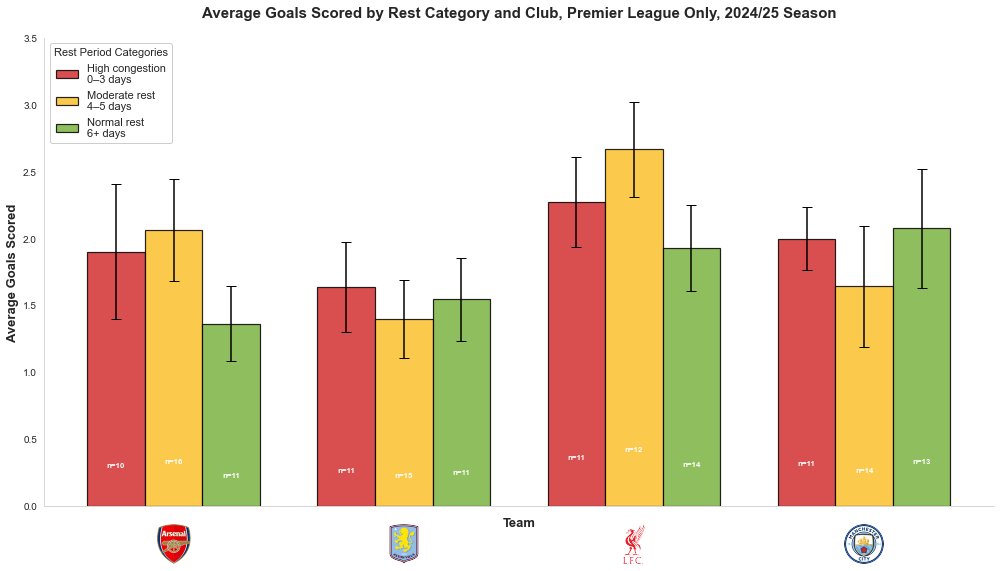

✓ Chart 5 (PL) saved: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/EDA/VISUALIZATIONS/05_Goals_by_Rest_Category_BarChart_PL.png

KEY INSIGHTS - REST PERIOD IMPACT ON GOALS (PREMIER LEAGUE)

Arsenal:
  • High congestion 0–3 days: 1.90 ± 1.60 goals (n=10 matches)
  • Moderate rest 4–5 days: 2.06 ± 1.53 goals (n=16 matches)
  • Normal rest 6+ days: 1.36 ± 0.92 goals (n=11 matches)

Aston Villa:
  • High congestion 0–3 days: 1.64 ± 1.12 goals (n=11 matches)
  • Moderate rest 4–5 days: 1.40 ± 1.12 goals (n=15 matches)
  • Normal rest 6+ days: 1.55 ± 1.04 goals (n=11 matches)

Liverpool:
  • High congestion 0–3 days: 2.27 ± 1.10 goals (n=11 matches)
  • Moderate rest 4–5 days: 2.67 ± 1.23 goals (n=12 matches)
  • Normal rest 6+ days: 1.93 ± 1.21 goals (n=14 matches)

Manchester City:
  • High congestion 0–3 days: 2.00 ± 0.77 goals (n=11 matches)
  • Moderate rest 4–5 days: 1.64 ± 1.69 goals (n=14 matches)
  • Normal rest 6+ days: 2.08 ± 1.61 goals (n=13 matches)



CHART 6: POINTS

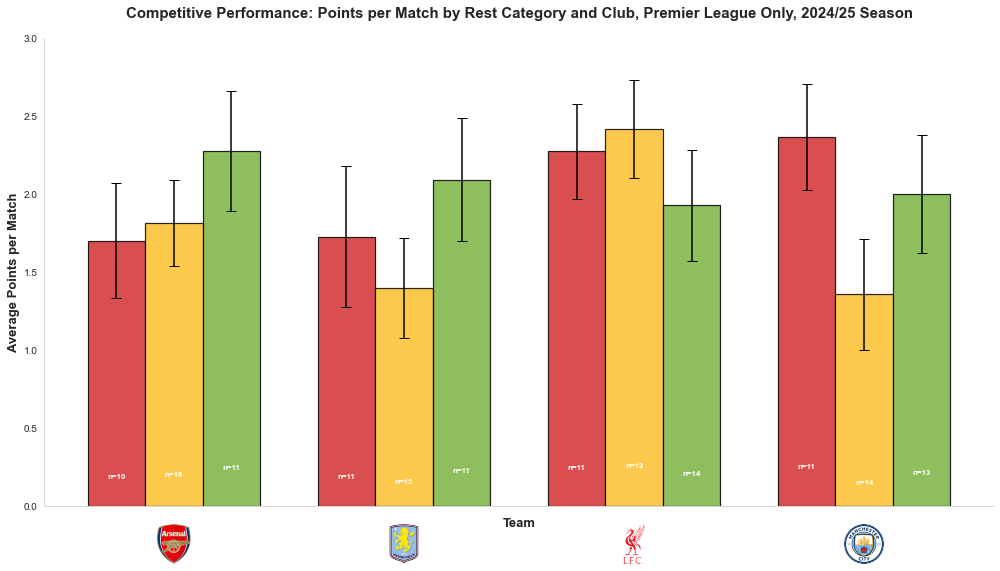

✓ Chart 6 (PL) saved: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/EDA/VISUALIZATIONS/06_Points_by_Rest_Category_BarChart_PL.png

KEY INSIGHTS - REST PERIOD IMPACT ON POINTS (PREMIER LEAGUE)

Arsenal:
  • High congestion 0–3 days: 1.70 pts/match (40.0% wins, n=10)
  • Moderate rest 4–5 days: 1.81 pts/match (43.8% wins, n=16)
  • Normal rest 6+ days: 2.27 pts/match (72.7% wins, n=11)

Aston Villa:
  • High congestion 0–3 days: 1.73 pts/match (54.5% wins, n=11)
  • Moderate rest 4–5 days: 1.40 pts/match (33.3% wins, n=15)
  • Normal rest 6+ days: 2.09 pts/match (63.6% wins, n=11)

Liverpool:
  • High congestion 0–3 days: 2.27 pts/match (63.6% wins, n=11)
  • Moderate rest 4–5 days: 2.42 pts/match (75.0% wins, n=12)
  • Normal rest 6+ days: 1.93 pts/match (57.1% wins, n=14)

Manchester City:
  • High congestion 0–3 days: 2.36 pts/match (72.7% wins, n=11)
  • Moderate rest 4–5 days: 1.36 pts/match (35.7% wins, n=14)
  • Normal rest 6+ days: 2.00 pts/match (61.5% wins, n=13)


Pe

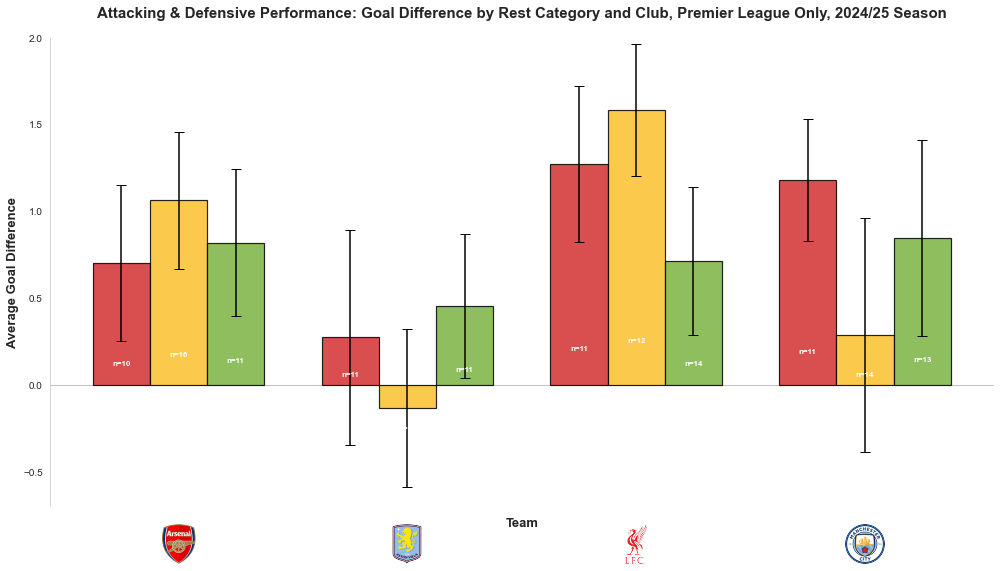

✓ Chart 7 (PL) saved: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/EDA/VISUALIZATIONS/07_Goal_Difference_by_Rest_Category_BarChart_PL.png

KEY INSIGHTS - REST PERIOD IMPACT ON GOAL DIFFERENCE (PREMIER LEAGUE)

Arsenal:
  • High congestion 0–3 days: +0.70 goal difference (n=10 matches)
  • Moderate rest 4–5 days: +1.06 goal difference (n=16 matches)
  • Normal rest 6+ days: +0.82 goal difference (n=11 matches)

Aston Villa:
  • High congestion 0–3 days: +0.27 goal difference (n=11 matches)
  • Moderate rest 4–5 days: -0.13 goal difference (n=15 matches)
  • Normal rest 6+ days: +0.45 goal difference (n=11 matches)

Liverpool:
  • High congestion 0–3 days: +1.27 goal difference (n=11 matches)
  • Moderate rest 4–5 days: +1.58 goal difference (n=12 matches)
  • Normal rest 6+ days: +0.71 goal difference (n=14 matches)

Manchester City:
  • High congestion 0–3 days: +1.18 goal difference (n=11 matches)
  • Moderate rest 4–5 days: +0.29 goal difference (n=14 matches)
  • Normal r

In [ ]:
# 9.0 CONGESTION VS PERFORMANCE ANALYSIS - PREMIER LEAGUE ONLY
# Three complementary visualizations revealing PL performance impact of rest periods from full calendar

print("\n" + "="*100)
print("CONGESTION VS PERFORMANCE: PREMIER LEAGUE IMPACT ANALYSIS")
print("="*100 + "\n")

# FILTER TO PREMIER LEAGUE MATCHES ONLY
pl_matches = master_matches_sorted[master_matches_sorted['competition'] == 'Premier League'].copy()
print(f"Total matches in analysis: {len(pl_matches)} Premier League matches\n")

# Reload team colors (ensure availability in this cell)
if 'team_colors' not in locals():
    team_colors = {
        'Arsenal': {'primary': '#EF0107', 'secondary': '#023474'},
        'Manchester City': {'primary': '#6CABDD', 'secondary': '#FFFFFF'},
        'Liverpool': {'primary': '#C8102E', 'secondary': '#FFFFFF'},
        'Aston Villa': {'primary': '#670E36', 'secondary': '#95BFE5'}
    }

# Define output directory for PNG files
output_dir = season_dir / 'VISUALIZATIONS'
output_dir.mkdir(exist_ok=True)

# Import PIL for logo handling
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Load team logos for x-axis
logos_dir = Path('/home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/EDA/LOGOS')
team_logo_files = {
    'Arsenal': 'england_arsenal_128x128.football-logos.cc.png',
    'Aston Villa': 'england_aston-villa_128x128.football-logos.cc.png',
    'Liverpool': 'england_liverpool_128x128.football-logos.cc.png',
    'Manchester City': 'england_manchester-city_128x128.football-logos.cc.png'
}

# Load and cache team logos
team_logo_cache = {}
LOGO_SIZE = (80, 80)

for team, filename in team_logo_files.items():
    logo_file = logos_dir / filename
    if logo_file.exists():
        try:
            img = Image.open(logo_file).convert('RGBA')
            img.thumbnail(LOGO_SIZE, Image.LANCZOS)
            transparent_img = Image.new('RGBA', LOGO_SIZE, (255, 255, 255, 0))
            offset_x = (LOGO_SIZE[0] - img.size[0]) // 2
            offset_y = (LOGO_SIZE[1] - img.size[1]) // 2
            transparent_img.paste(img, (offset_x, offset_y), img)
            team_logo_cache[team] = transparent_img
        except Exception as e:
            print(f"Warning: Could not load logo for {team}: {e}")

# Define rest categories
rest_bins = [0, 3, 5, 100]
rest_labels = ["High congestion\n0–3 days", "Moderate rest\n4–5 days", "Normal rest\n6+ days"]

# Create rest category column for PL matches (using rest_days from full calendar)
pl_matches['rest_category'] = pd.cut(
    pl_matches['days_since_previous_match'],
    bins=rest_bins,
    labels=rest_labels,
    include_lowest=True
)

teams_list = sorted(pl_matches['team'].unique())

print("\n" + "="*100)
print("CHART 5: AVERAGE GOALS SCORED BY REST CATEGORY (PREMIER LEAGUE)")
print("="*100 + "\n")

# Calculate summary statistics FOR PL MATCHES ONLY
summary = (
    pl_matches.groupby(['team', 'rest_category'], observed=True)
    .agg(
        avg_goals=('goals_for', 'mean'),
        std_goals=('goals_for', 'std'),
        matches=('goals_for', 'count')
    )
    .reset_index()
)

# Calculate standard error of the mean (SEM)
summary['sem_goals'] = summary['std_goals'] / np.sqrt(summary['matches'])
summary['n'] = summary['matches']

print("SUMMARY STATISTICS - GOALS BY REST CATEGORY (PREMIER LEAGUE ONLY, 2024-2025)\n")
print(summary.to_string(index=False))
print("\n")

# Create the bar chart
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(teams_list))
bar_width = 0.25
colors = ['#D32F2F', '#FBC02D', '#7CB342']

for idx, rest_cat in enumerate(rest_labels):
    rest_data = summary[summary['rest_category'] == rest_cat]
    rest_data = rest_data.set_index('team').reindex(teams_list).reset_index()
    
    avg_goals = rest_data['avg_goals'].values
    sem_goals = rest_data['sem_goals'].fillna(0).values
    n_matches = rest_data['n'].values
    
    bars = ax.bar(
        x + (idx - 1) * bar_width,
        avg_goals,
        bar_width,
        label=rest_cat,
        color=colors[idx],
        alpha=0.85,
        edgecolor='black',
        linewidth=1.2,
        yerr=sem_goals,
        capsize=5,
        error_kw={'linewidth': 1.5, 'ecolor': 'black'}
    )
    
    for i, (bar, n) in enumerate(zip(bars, n_matches)):
        height = bar.get_height()
        if not np.isnan(height):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height * 0.15,
                f'n={int(n)}',
                ha='center',
                va='bottom',
                fontsize=8,
                fontweight='bold',
                color='white'
            )

ax.set_xlabel('Team', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Goals Scored', fontsize=13, fontweight='bold')
ax.set_title('Average Goals Scored by Rest Category and Club, Premier League Only, 2024/25 Season', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels([])

for idx, team in enumerate(teams_list):
    if team in team_logo_cache:
        logo_img = team_logo_cache[team]
        imagebox = OffsetImage(logo_img, zoom=0.50)
        ab = AnnotationBbox(imagebox, (x[idx], -0.08), xycoords=('data', 'axes fraction'),
                           frameon=False, pad=0, annotation_clip=False)
        ax.add_artist(ab)

ax.legend(fontsize=11, loc='upper left', framealpha=0.95, 
          title='Rest Period Categories', title_fontsize=11)
ax.grid(False)
ax.set_ylim(0, 3.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)

plt.tight_layout()
plt.show()

chart_file = output_dir / '05_Goals_by_Rest_Category_BarChart_PL_2024_25.png'
fig.savefig(chart_file, dpi=300, bbox_inches='tight')
print(f"✓ Chart 5 (PL) saved: {chart_file}\n")

print("="*100)
print("KEY INSIGHTS - REST PERIOD IMPACT ON GOALS (PREMIER LEAGUE)")
print("="*100 + "\n")

for team in teams_list:
    team_summary = summary[summary['team'] == team]
    print(f"{team}:")
    for _, row in team_summary.iterrows():
        rest_cat = row['rest_category']
        avg = row['avg_goals']
        std = row['std_goals']
        n = int(row['matches'])
        print(f"  • {rest_cat.replace(chr(10), ' ')}: {avg:.2f} ± {std:.2f} goals (n={n} matches)")
    print()

print("="*100 + "\n")

# ============================================================================
# CHART 6: POINTS PER MATCH BY REST CATEGORY (PL ONLY)
# ============================================================================
print("\n" + "="*100)
print("CHART 6: POINTS PER MATCH BY REST CATEGORY (PREMIER LEAGUE)")
print("="*100 + "\n")

points_summary = (
    pl_matches
    .dropna(subset=['points', 'rest_category'])
    .groupby(['team', 'rest_category'], observed=True)
    .agg(
        avg_points=('points', 'mean'),
        sem_points=('points', lambda x: x.std() / np.sqrt(len(x))),
        matches=('points', 'count'),
        win_rate=('result', lambda x: (x == 'W').mean() * 100)
    )
    .reset_index()
)

points_summary['n'] = points_summary['matches']

print("SUMMARY TABLE - POINTS PER MATCH BY REST CATEGORY (PREMIER LEAGUE ONLY)\n")
display_table = points_summary[['team', 'rest_category', 'n', 'avg_points', 'win_rate']].copy()
display_table.columns = ['Team', 'Rest Category', 'Matches', 'Points/Match', 'Win Rate (%)']
display_table['Win Rate (%)'] = display_table['Win Rate (%)'].round(1)
display_table['Points/Match'] = display_table['Points/Match'].round(2)
print(display_table.to_string(index=False))
print("\n")

fig_points, ax_points = plt.subplots(figsize=(14, 8))

x = np.arange(len(teams_list))
bar_width = 0.25
colors = ['#D32F2F', '#FBC02D', '#7CB342']

for idx, rest_cat in enumerate(rest_labels):
    rest_data = points_summary[points_summary['rest_category'] == rest_cat]
    rest_data = rest_data.set_index('team').reindex(teams_list).reset_index()
    
    avg_points = rest_data['avg_points'].values
    sem_points = rest_data['sem_points'].fillna(0).values
    n_matches = rest_data['n'].values
    
    bars = ax_points.bar(
        x + (idx - 1) * bar_width,
        avg_points,
        bar_width,
        label=rest_cat,
        color=colors[idx],
        alpha=0.85,
        edgecolor='black',
        linewidth=1.2,
        yerr=sem_points,
        capsize=5,
        error_kw={'linewidth': 1.5, 'ecolor': 'black'}
    )
    
    for i, (bar, n) in enumerate(zip(bars, n_matches)):
        height = bar.get_height()
        if not np.isnan(height):
            ax_points.text(
                bar.get_x() + bar.get_width() / 2,
                height * 0.10,
                f'n={int(n)}',
                ha='center',
                va='bottom',
                fontsize=8,
                fontweight='bold',
                color='white'
            )

ax_points.set_xlabel('Team', fontsize=13, fontweight='bold')
ax_points.set_ylabel('Average Points per Match', fontsize=13, fontweight='bold')
ax_points.set_title('Competitive Performance: Points per Match by Rest Category and Club, Premier League Only, 2024/25 Season', 
             fontsize=15, fontweight='bold', pad=20)
ax_points.set_xticks(x)
ax_points.set_xticklabels([])

for idx, team in enumerate(teams_list):
    if team in team_logo_cache:
        logo_img = team_logo_cache[team]
        imagebox = OffsetImage(logo_img, zoom=0.50)
        ab = AnnotationBbox(imagebox, (x[idx], -0.08), xycoords=('data', 'axes fraction'),
                           frameon=False, pad=0, annotation_clip=False)
        ax_points.add_artist(ab)

ax_points.grid(False)
ax_points.set_ylim(0, 3)
ax_points.spines['top'].set_visible(False)
ax_points.spines['right'].set_visible(False)
ax_points.spines['bottom'].set_visible(True)

plt.tight_layout()
plt.show()

chart_file = output_dir / '06_Points_by_Rest_Category_BarChart_PL_2024_25.png'
fig_points.savefig(chart_file, dpi=300, bbox_inches='tight')
print(f"✓ Chart 6 (PL) saved: {chart_file}\n")

print("="*100)
print("KEY INSIGHTS - REST PERIOD IMPACT ON POINTS (PREMIER LEAGUE)")
print("="*100 + "\n")

for team in teams_list:
    team_data = points_summary[points_summary['team'] == team]
    print(f"{team}:")
    for _, row in team_data.iterrows():
        rest_cat = row['rest_category'].replace('\n', ' ')
        avg_pts = row['avg_points']
        win_rate = row['win_rate']
        n = int(row['matches'])
        print(f"  • {rest_cat}: {avg_pts:.2f} pts/match ({win_rate:.1f}% wins, n={n})")
    print()

rest_category_perf = pl_matches.dropna(subset=['points', 'rest_category']).groupby('rest_category', observed=True).agg({
    'points': ['mean', 'std', 'count'],
    'result': lambda x: (x == 'W').mean() * 100
}).round(2)

rest_category_perf.columns = ['avg_points', 'std_points', 'match_count', 'win_rate']
rest_category_perf = rest_category_perf.reindex(rest_labels)

print("\nPerformance Summary Across All Teams (by Rest Category) - PREMIER LEAGUE:")
for rest_cat in rest_labels:
    row = rest_category_perf.loc[rest_cat]
    print(f"  {rest_cat.replace(chr(10), ' ')}:")
    print(f"    • Avg points/match: {row['avg_points']:.2f}")
    print(f"    • Win rate: {row['win_rate']:.1f}%")
    print(f"    • Matches: {int(row['match_count'])}")
    print()

print("="*100 + "\n")

# ============================================================================
# CHART 7: GOAL DIFFERENCE BY REST CATEGORY (PL ONLY)
# ============================================================================
print("\n" + "="*100)
print("CHART 7: GOAL DIFFERENCE BY REST CATEGORY (PREMIER LEAGUE)")
print("="*100 + "\n")

gd_summary = (
    pl_matches
    .dropna(subset=['goal_difference', 'rest_category'])
    .groupby(['team', 'rest_category'], observed=True)
    .agg(
        avg_goal_difference=('goal_difference', 'mean'),
        sem_goal_difference=('goal_difference', lambda x: x.std() / np.sqrt(len(x))),
        matches=('goal_difference', 'count')
    )
    .reset_index()
)

gd_summary['n'] = gd_summary['matches']

print("SUMMARY TABLE - GOAL DIFFERENCE BY REST CATEGORY (PREMIER LEAGUE ONLY)\n")
display_table_gd = gd_summary[['team', 'rest_category', 'n', 'avg_goal_difference']].copy()
display_table_gd.columns = ['Team', 'Rest Category', 'Matches', 'Goal Difference']
display_table_gd['Goal Difference'] = display_table_gd['Goal Difference'].round(2)
print(display_table_gd.to_string(index=False))
print("\n")

fig_gd, ax_gd = plt.subplots(figsize=(14, 8))

x = np.arange(len(teams_list))
bar_width = 0.25
colors = ['#D32F2F', '#FBC02D', '#7CB342']

for idx, rest_cat in enumerate(rest_labels):
    rest_data = gd_summary[gd_summary['rest_category'] == rest_cat]
    rest_data = rest_data.set_index('team').reindex(teams_list).reset_index()
    
    avg_goal_difference = rest_data['avg_goal_difference'].values
    sem_goal_diff = rest_data['sem_goal_difference'].fillna(0).values
    n_matches = rest_data['n'].values
    
    bars = ax_gd.bar(
        x + (idx - 1) * bar_width,
        avg_goal_difference,
        bar_width,
        label=rest_cat,
        color=colors[idx],
        alpha=0.85,
        edgecolor='black',
        linewidth=1.2,
        yerr=sem_goal_diff,
        capsize=5,
        error_kw={'linewidth': 1.5, 'ecolor': 'black'}
    )
    
    for i, (bar, n) in enumerate(zip(bars, n_matches)):
        height = bar.get_height()
        if not np.isnan(height):
            ax_gd.text(
                bar.get_x() + bar.get_width() / 2,
                height * 0.15 if height > 0 else height - 0.1,
                f'n={int(n)}',
                ha='center',
                va='bottom' if height > 0 else 'top',
                fontsize=8,
                fontweight='bold',
                color='white'
            )

ax_gd.set_xlabel('Team', fontsize=13, fontweight='bold')
ax_gd.set_ylabel('Average Goal Difference', fontsize=13, fontweight='bold')
ax_gd.set_title('Attacking & Defensive Performance: Goal Difference by Rest Category and Club, Premier League Only, 2024/25 Season', 
             fontsize=15, fontweight='bold', pad=20)
ax_gd.set_xticks(x)
ax_gd.set_xticklabels([])

# Add zero reference line
ax_gd.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)

for idx, team in enumerate(teams_list):
    if team in team_logo_cache:
        logo_img = team_logo_cache[team]
        imagebox = OffsetImage(logo_img, zoom=0.50)
        ab = AnnotationBbox(imagebox, (x[idx], -0.08), xycoords=('data', 'axes fraction'),
                           frameon=False, pad=0, annotation_clip=False)
        ax_gd.add_artist(ab)

ax_gd.grid(False)
ax_gd.set_ylim(-0.7, 2.0)
ax_gd.spines['top'].set_visible(False)
ax_gd.spines['right'].set_visible(False)
ax_gd.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()

chart_file = output_dir / '07_Goal_Difference_by_Rest_Category_BarChart_PL_2024_25.png'
fig_gd.savefig(chart_file, dpi=300, bbox_inches='tight')
print(f"✓ Chart 7 (PL) saved: {chart_file}\n")

print("="*100)
print("KEY INSIGHTS - REST PERIOD IMPACT ON GOAL DIFFERENCE (PREMIER LEAGUE)")
print("="*100 + "\n")

for team in teams_list:
    team_data = gd_summary[gd_summary['team'] == team]
    print(f"{team}:")
    for _, row in team_data.iterrows():
        rest_cat = row['rest_category'].replace('\n', ' ')
        avg_gd = row['avg_goal_difference']
        n = int(row['matches'])
        print(f"  • {rest_cat}: {avg_gd:+.2f} goal difference (n={n} matches)")
    print()

print("="*100)
print("✓ ALL THREE PREMIER LEAGUE ANALYSES COMPLETE")
print("="*100 + "\n")



CHART 3: AVERAGE GOALS CONCEDED BY REST CATEGORY (PREMIER LEAGUE)

SUMMARY STATISTICS - GOALS CONCEDED BY REST CATEGORY (PREMIER LEAGUE ONLY)

           team             rest_category  avg_goals_against  sem_goals_against  matches  n
        Arsenal High congestion\n0–3 days           1.200000           0.249444       10 10
        Arsenal   Moderate rest\n4–5 days           1.000000           0.182574       16 16
        Arsenal      Normal rest\n6+ days           0.545455           0.207305       11 11
    Aston Villa High congestion\n0–3 days           1.363636           0.363636       11 11
    Aston Villa   Moderate rest\n4–5 days           1.533333           0.306542       15 15
    Aston Villa      Normal rest\n6+ days           1.090909           0.250619       11 11
      Liverpool High congestion\n0–3 days           1.000000           0.301511       11 11
      Liverpool   Moderate rest\n4–5 days           1.083333           0.336162       12 12
      Liverpool      Normal 

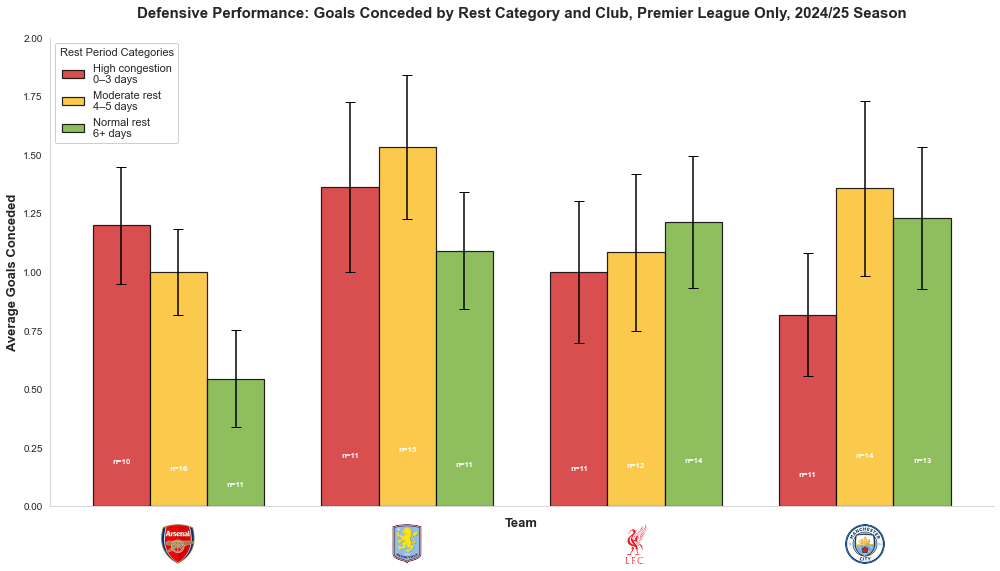

✓ Chart 3 (PL) saved: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/EDA/VISUALIZATIONS/03_Goals_Conceded_by_Rest_Category_BarChart_PL.png

KEY INSIGHTS - REST PERIOD IMPACT ON DEFENSIVE PERFORMANCE (PREMIER LEAGUE)

Arsenal:
  • High congestion 0–3 days: 1.20 ± 0.25 goals conceded (n=10 matches)
  • Moderate rest 4–5 days: 1.00 ± 0.18 goals conceded (n=16 matches)
  • Normal rest 6+ days: 0.55 ± 0.21 goals conceded (n=11 matches)

Aston Villa:
  • High congestion 0–3 days: 1.36 ± 0.36 goals conceded (n=11 matches)
  • Moderate rest 4–5 days: 1.53 ± 0.31 goals conceded (n=15 matches)
  • Normal rest 6+ days: 1.09 ± 0.25 goals conceded (n=11 matches)

Liverpool:
  • High congestion 0–3 days: 1.00 ± 0.30 goals conceded (n=11 matches)
  • Moderate rest 4–5 days: 1.08 ± 0.34 goals conceded (n=12 matches)
  • Normal rest 6+ days: 1.21 ± 0.28 goals conceded (n=14 matches)

Manchester City:
  • High congestion 0–3 days: 0.82 ± 0.26 goals conceded (n=11 matches)
  • Moderate rest 4–5 

In [ ]:
# ============================================================================
# CHART 3: GOALS CONCEDED BY REST CATEGORY - DEFENSIVE FATIGUE ANALYSIS (PL ONLY)
# ============================================================================
print("\n" + "="*100)
print("CHART 3: AVERAGE GOALS CONCEDED BY REST CATEGORY (PREMIER LEAGUE)")
print("="*100 + "\n")

# Defensive Impact: Do teams concede more when rest is short?
# Congestion can cause defensive fatigue, slower pressing, more mistakes, and poorer transitions

ga_summary = (
    pl_matches
    .dropna(subset=['goals_against', 'rest_category'])
    .groupby(['team', 'rest_category'], observed=True)
    .agg(
        avg_goals_against=('goals_against', 'mean'),
        sem_goals_against=('goals_against', lambda x: x.std() / np.sqrt(len(x))),
        matches=('goals_against', 'count')
    )
    .reset_index()
)

ga_summary['n'] = ga_summary['matches']

print("SUMMARY STATISTICS - GOALS CONCEDED BY REST CATEGORY (PREMIER LEAGUE ONLY, 2024-2025)\n")
print(ga_summary.to_string(index=False))
print("\n")

# Create the bar chart for goals conceded
fig_ga, ax_ga = plt.subplots(figsize=(14, 8))

x = np.arange(len(teams_list))
bar_width = 0.25
colors = ['#D32F2F', '#FBC02D', '#7CB342']

for idx, rest_cat in enumerate(rest_labels):
    rest_data = ga_summary[ga_summary['rest_category'] == rest_cat]
    rest_data = rest_data.set_index('team').reindex(teams_list).reset_index()
    
    avg_goals_against = rest_data['avg_goals_against'].values
    sem_goals_against = rest_data['sem_goals_against'].fillna(0).values
    n_matches = rest_data['n'].values
    
    bars = ax_ga.bar(
        x + (idx - 1) * bar_width,
        avg_goals_against,
        bar_width,
        label=rest_cat,
        color=colors[idx],
        alpha=0.85,
        edgecolor='black',
        linewidth=1.2,
        yerr=sem_goals_against,
        capsize=5,
        error_kw={'linewidth': 1.5, 'ecolor': 'black'}
    )
    
    for i, (bar, n) in enumerate(zip(bars, n_matches)):
        height = bar.get_height()
        if not np.isnan(height):
            ax_ga.text(
                bar.get_x() + bar.get_width() / 2,
                height * 0.15,
                f'n={int(n)}',
                ha='center',
                va='bottom',
                fontsize=8,
                fontweight='bold',
                color='white'
            )

ax_ga.set_xlabel('Team', fontsize=13, fontweight='bold')
ax_ga.set_ylabel('Average Goals Conceded', fontsize=13, fontweight='bold')
ax_ga.set_title('Defensive Performance: Goals Conceded by Rest Category and Club, Premier League Only, 2024/25 Season', 
             fontsize=15, fontweight='bold', pad=20)
ax_ga.set_xticks(x)
ax_ga.set_xticklabels([])

ax_ga.legend(fontsize=11, loc='upper left', framealpha=0.95, 
          title='Rest Period Categories', title_fontsize=11)

for idx, team in enumerate(teams_list):
    if team in team_logo_cache:
        logo_img = team_logo_cache[team]
        imagebox = OffsetImage(logo_img, zoom=0.50)
        ab = AnnotationBbox(imagebox, (x[idx], -0.08), xycoords=('data', 'axes fraction'),
                           frameon=False, pad=0, annotation_clip=False)
        ax_ga.add_artist(ab)

ax_ga.grid(False)
ax_ga.set_ylim(0, 2.0)
ax_ga.spines['top'].set_visible(False)
ax_ga.spines['right'].set_visible(False)
ax_ga.spines['bottom'].set_visible(True)

plt.tight_layout()
plt.show()

chart_file = output_dir / '03_Goals_Conceded_by_Rest_Category_BarChart_PL_2024_25.png'
fig_ga.savefig(chart_file, dpi=300, bbox_inches='tight')
print(f"✓ Chart 3 (PL) saved: {chart_file}\n")

print("="*100)
print("KEY INSIGHTS - REST PERIOD IMPACT ON DEFENSIVE PERFORMANCE (PREMIER LEAGUE)")
print("="*100 + "\n")

for team in teams_list:
    team_data = ga_summary[ga_summary['team'] == team]
    print(f"{team}:")
    for _, row in team_data.iterrows():
        rest_cat = row['rest_category']
        avg_ga = row['avg_goals_against']
        std_ga = row['sem_goals_against']
        n = int(row['matches'])
        print(f"  • {rest_cat.replace(chr(10), ' ')}: {avg_ga:.2f} ± {std_ga:.2f} goals conceded (n={n} matches)")
    print()

# Overall analysis
rest_category_defensive = pl_matches.dropna(subset=['goals_against', 'rest_category']).groupby('rest_category', observed=True).agg({
    'goals_against': ['mean', 'std', 'count']
}).round(2)

rest_category_defensive.columns = ['avg_ga', 'std_ga', 'match_count']
rest_category_defensive = rest_category_defensive.reindex(rest_labels)

print("\nDefensive Performance Summary Across All Teams (by Rest Category) - PREMIER LEAGUE:")
for rest_cat in rest_labels:
    row = rest_category_defensive.loc[rest_cat]
    print(f"  {rest_cat.replace(chr(10), ' ')}:")
    print(f"    • Avg goals conceded: {row['avg_ga']:.2f}")
    print(f"    • Matches: {int(row['match_count'])}")
    print()

print("="*100)
print("✓ DEFENSIVE FATIGUE ANALYSIS COMPLETE (PREMIER LEAGUE)")
print("="*100 + "\n")


### 3.2 European Hangover Effect on Premier League (Analysis 6)

**Question**: Do Premier League teams underperform when their previous match was a Champions League fixture?

**Dataset**: Premier League matches only, stratified by 'after_europe' flag

**Key Metrics**:
- Points per match (PPM) after Europe vs other PL matches
- Win rate comparison
- Goals for/against differential
- Expected finding: -10% to -15% PPM dip after European fixtures (fatigue/recovery)


CHART 4: WIN/DRAW/LOSS DISTRIBUTION BY REST CATEGORY (PREMIER LEAGUE)

SUMMARY TABLE - WIN/DRAW/LOSS DISTRIBUTION BY REST CATEGORY (PREMIER LEAGUE ONLY)

Team              Rest Category              Win %    Draw %   Loss %    Total Matches
------------------------------------------------------------------------------------------
Arsenal         High congestion 0–3 days    40.0    50.0    10.0    10
Arsenal         Moderate rest 4–5 days      43.8    50.0     6.2    16
Arsenal         Normal rest 6+ days         72.7     9.1    18.2    11
Aston Villa     High congestion 0–3 days    54.5     9.1    36.4    11
Aston Villa     Moderate rest 4–5 days      33.3    40.0    26.7    15
Aston Villa     Normal rest 6+ days         63.6    18.2    18.2    11
Liverpool       High congestion 0–3 days    63.6    36.4     0.0    11
Liverpool       Moderate rest 4–5 days      75.0    16.7     8.3    12
Liverpool       Normal rest 6+ days         57.1    21.4    21.4    14
Manchester City High congest

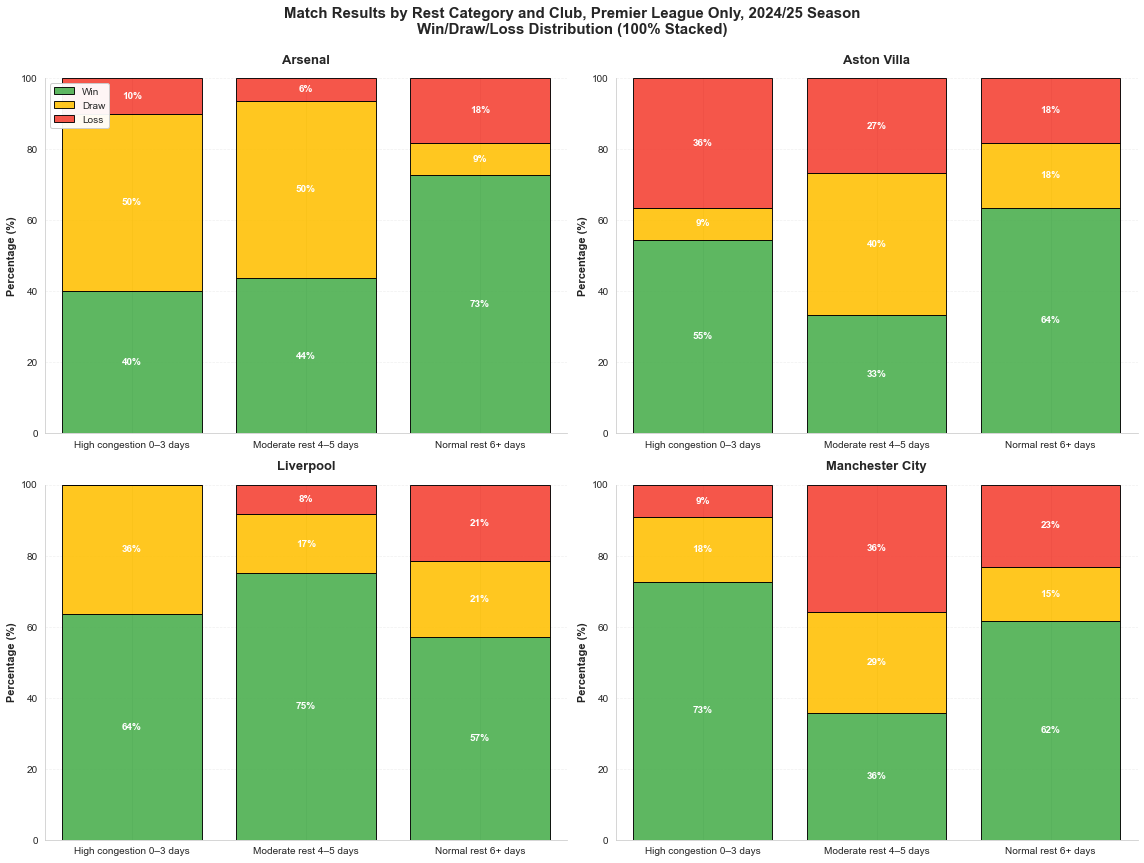

✓ Chart 4 (PL) saved: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/EDA/VISUALIZATIONS/04_Match_Results_by_Rest_Category_100pStacked_PL.png

KEY INSIGHTS - MATCH RESULTS BY REST CATEGORY (PREMIER LEAGUE)

High congestion 0–3 days (n=43 matches):
  • Average Win %: 57.7%
  • Average Draw %: 28.4%
  • Average Loss %: 13.9%

Moderate rest 4–5 days (n=57 matches):
  • Average Win %: 47.0%
  • Average Draw %: 33.8%
  • Average Loss %: 19.2%

Normal rest 6+ days (n=49 matches):
  • Average Win %: 63.7%
  • Average Draw %: 16.0%
  • Average Loss %: 20.2%


Team-Specific Observations:
Arsenal: Results stable across rest categories
Aston Villa: Win rate drops 21.2pp at moderate rest
Liverpool: Loss rate rises 8.3pp at moderate rest
Manchester City: Win rate drops 37.0pp at moderate rest

✓ MATCH RESULTS ANALYSIS COMPLETE (PREMIER LEAGUE)



In [55]:
# ============================================================================
# CHART 4: WIN/DRAW/LOSS DISTRIBUTION BY REST CATEGORY - MATCH RESULTS (PL ONLY)
# ============================================================================
print("\n" + "="*100)
print("CHART 4: WIN/DRAW/LOSS DISTRIBUTION BY REST CATEGORY (PREMIER LEAGUE)")
print("="*100 + "\n")

# Result distribution analysis: Do congested matches have more draws/losses?
# 100% stacked bar chart showing W/D/L percentages by rest category and team

result_dist = (
    pl_matches
    .dropna(subset=['result', 'rest_category'])
    .groupby(['team', 'rest_category', 'result'], observed=True)
    .size()
    .reset_index(name='count')
)

result_dist['total'] = result_dist.groupby(['team', 'rest_category'], observed=True)['count'].transform('sum')
result_dist['percentage'] = result_dist['count'] / result_dist['total'] * 100

# Pivot to get W/D/L percentages for each team-rest category combination
result_pivot = result_dist.pivot_table(
    index=['team', 'rest_category'],
    columns='result',
    values='percentage',
    fill_value=0,
    observed=True
)

# Ensure all result types exist (W, D, L)
for col in ['W', 'D', 'L']:
    if col not in result_pivot.columns:
        result_pivot[col] = 0

result_pivot = result_pivot[['W', 'D', 'L']]
result_pivot = result_pivot.reset_index()

print("SUMMARY TABLE - WIN/DRAW/LOSS DISTRIBUTION BY REST CATEGORY (PREMIER LEAGUE ONLY)\n")
print("Team              Rest Category              Win %    Draw %   Loss %    Total Matches")
print("-" * 90)

result_summary_table = pl_matches.dropna(subset=['result', 'rest_category']).groupby(
    ['team', 'rest_category'], observed=True
).agg(
    Wins=('result', lambda x: (x == 'W').sum()),
    Draws=('result', lambda x: (x == 'D').sum()),
    Losses=('result', lambda x: (x == 'L').sum()),
    Total=('result', 'count')
).reset_index()

result_summary_table['Win %'] = (result_summary_table['Wins'] / result_summary_table['Total'] * 100).round(1)
result_summary_table['Draw %'] = (result_summary_table['Draws'] / result_summary_table['Total'] * 100).round(1)
result_summary_table['Loss %'] = (result_summary_table['Losses'] / result_summary_table['Total'] * 100).round(1)

for _, row in result_summary_table.iterrows():
    rest_label = row['rest_category'].replace('\n', ' ')
    print(f"{row['team']:15} {rest_label:25} {row['Win %']:6.1f}  {row['Draw %']:6.1f}  {row['Loss %']:6.1f}    {int(row['Total']):2.0f}")

print("\n")

# Create 100% stacked bar chart with team facets (2x2 grid)
fig_result, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

result_colors = {'W': '#4CAF50', 'D': '#FFC107', 'L': '#F44336'}
result_labels = {'W': 'Win', 'D': 'Draw', 'L': 'Loss'}

for team_idx, team in enumerate(teams_list):
    ax = axes[team_idx]
    team_result_data = result_pivot[result_pivot['team'] == team]
    
    if team_result_data.empty:
        continue
    
    # Reset index for plotting
    team_result_data = team_result_data.reset_index(drop=True)
    
    x_pos = np.arange(len(team_result_data))
    
    # Create 100% stacked bars
    bottom = np.zeros(len(team_result_data))
    
    for result, color in [('W', result_colors['W']), ('D', result_colors['D']), ('L', result_colors['L'])]:
        values = team_result_data[result].values
        bars = ax.bar(
            x_pos,
            values,
            bottom=bottom,
            label=result_labels[result],
            color=color,
            edgecolor='black',
            linewidth=1,
            alpha=0.9
        )
        
        # Add percentage labels on each segment
        for i, (bar, val) in enumerate(zip(bars, values)):
            if val > 3:  # Only show label if segment is wide enough
                height = bar.get_height()
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bottom[i] + height / 2,
                    f'{val:.0f}%',
                    ha='center',
                    va='center',
                    fontsize=10,
                    fontweight='bold',
                    color='white'
                )
        
        bottom += values
    
    # Configure each subplot
    ax.set_ylim(0, 100)
    ax.set_xlim(-0.5, len(team_result_data) - 0.5)
    ax.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([rc.replace('\n', ' ') for rc in team_result_data['rest_category']], fontsize=10)
    ax.set_title(f'{team}', fontsize=13, fontweight='bold', pad=15)
    
    # Add horizontal gridlines for readability
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
    ax.set_axisbelow(True)
    
    # Legend only on first subplot
    if team_idx == 0:
        ax.legend(loc='upper left', fontsize=10, framealpha=0.95)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig_result.suptitle(
    'Match Results by Rest Category and Club, Premier League Only, 2024/25 Season\nWin/Draw/Loss Distribution (100% Stacked)',
    fontsize=15,
    fontweight='bold',
    y=0.995
)

plt.tight_layout()
plt.show()

chart_file = output_dir / '04_Match_Results_by_Rest_Category_100pStacked_PL.png'
fig_result.savefig(chart_file, dpi=300, bbox_inches='tight')
print(f"✓ Chart 4 (PL) saved: {chart_file}\n")

print("="*100)
print("KEY INSIGHTS - MATCH RESULTS BY REST CATEGORY (PREMIER LEAGUE)")
print("="*100 + "\n")

# Analyze overall trends
for rest_cat in rest_labels:
    rest_cat_data = result_summary_table[result_summary_table['rest_category'] == rest_cat]
    avg_win_pct = rest_cat_data['Win %'].mean()
    avg_draw_pct = rest_cat_data['Draw %'].mean()
    avg_loss_pct = rest_cat_data['Loss %'].mean()
    total_matches = rest_cat_data['Total'].sum()
    
    print(f"{rest_cat.replace(chr(10), ' ')} (n={total_matches} matches):")
    print(f"  • Average Win %: {avg_win_pct:.1f}%")
    print(f"  • Average Draw %: {avg_draw_pct:.1f}%")
    print(f"  • Average Loss %: {avg_loss_pct:.1f}%")
    print()

# Team-specific insights
print("\nTeam-Specific Observations:")
for team in teams_list:
    team_data = result_summary_table[result_summary_table['team'] == team].sort_values('rest_category')
    high_cong = team_data[team_data['rest_category'].str.contains('High')].iloc[0] if len(team_data) > 0 else None
    moderate = team_data[team_data['rest_category'].str.contains('Moderate')].iloc[0] if len(team_data) > 0 else None
    normal = team_data[team_data['rest_category'].str.contains('Normal')].iloc[0] if len(team_data) > 0 else None
    
    if high_cong is not None and moderate is not None:
        win_diff = moderate['Win %'] - high_cong['Win %']
        loss_diff = moderate['Loss %'] - high_cong['Loss %']
        print(f"{team}: ", end="")
        if win_diff < -5:
            print(f"Win rate drops {abs(win_diff):.1f}pp at moderate rest")
        elif loss_diff > 5:
            print(f"Loss rate rises {loss_diff:.1f}pp at moderate rest")
        else:
            print(f"Results stable across rest categories")

print("\n" + "="*100)
print("✓ MATCH RESULTS ANALYSIS COMPLETE (PREMIER LEAGUE)")
print("="*100 + "\n")


### 3.3 Time-Series Correlation: Rolling Congestion vs Performance (Analysis 7)

**Question**: As fixture density increases throughout the season, does rolling team performance decline?

**Dataset**: Premier League matches only

**Visualization**: 4-panel time series (one per team)
- Left axis: Gray bars = matches in last 14 days (0-6 scale)
- Right axis: Colored line = 5-match rolling average points per match (0-3.5 scale)
- X-axis: Season timeline from August to May

**Expected insight**: Weak negative correlation (r ≈ -0.15 to -0.25) indicating teams slow down under congestion, but not deterministically.


ANALYSIS 6: EUROPEAN HANGOVER EFFECT - PREMIER LEAGUE PERFORMANCE AFTER EUROPEAN FIXTURES

SUMMARY TABLE - EUROPEAN HANGOVER ANALYSIS (PREMIER LEAGUE ONLY)

Team              Context                  Matches  PPM    GF     GA     GD     Win %
-----------------------------------------------------------------------------------------------
Arsenal         Other PL matches           26       2.19   2.04   0.81   1.23    61.5%
Arsenal         PL after Europe            12       1.42   1.33   1.08   0.25    33.3%
Aston Villa     Other PL matches           27       1.63   1.37   1.33   0.04    48.1%
Aston Villa     PL after Europe            11       2.00   1.91   1.36   0.55    54.5%
Liverpool       Other PL matches           30       2.10   2.27   1.10   1.17    60.0%
Liverpool       PL after Europe             8       2.62   2.25   1.00   1.25    87.5%
Manchester City Other PL matches           29       1.86   1.76   1.10   0.66    55.2%
Manchester City PL after Europe             9      

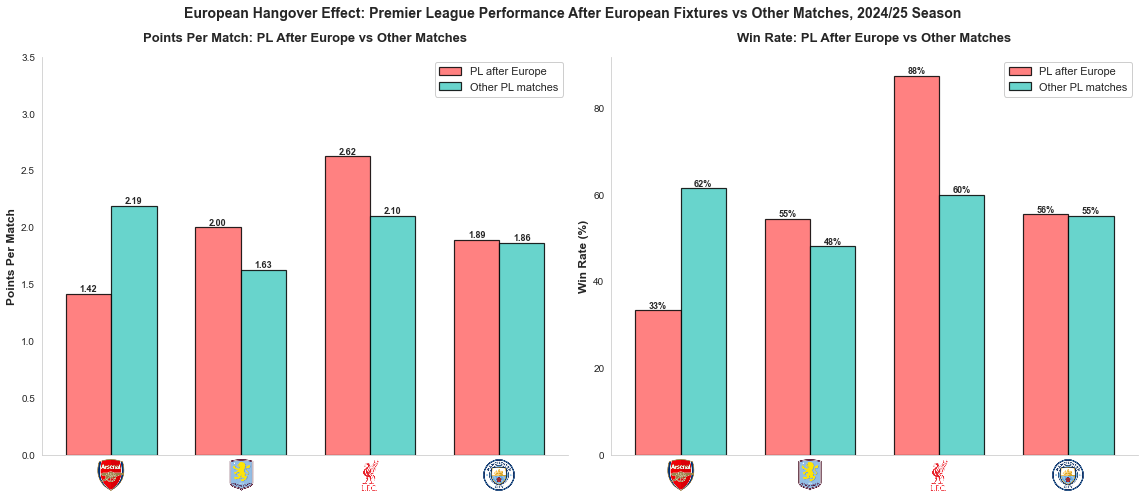

✓ Chart 5 (PL) saved: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/EDA/VISUALIZATIONS/05_European_Hangover_Effect_Analysis_PL.png

KEY INSIGHTS - EUROPEAN HANGOVER EFFECT (PREMIER LEAGUE)

Arsenal:
  • PL after Europe: 12 matches | PPM: 1.42 | Win Rate: 33.3%
  • Other PL matches: 26 matches | PPM: 2.19 | Win Rate: 61.5%
  • HANGOVER IMPACT: PPM change -0.78 (-35.4%) | Win rate change -28.2pp
  • Offensive impact: Goals For -0.71 | Defensive impact: Goals Against +0.28
  • Assessment: SEVERE HANGOVER - Significant performance drop after Europe

Aston Villa:
  • PL after Europe: 11 matches | PPM: 2.00 | Win Rate: 54.5%
  • Other PL matches: 27 matches | PPM: 1.63 | Win Rate: 48.1%
  • HANGOVER IMPACT: PPM change +0.37 (+22.7%) | Win rate change +6.4pp
  • Offensive impact: Goals For +0.54 | Defensive impact: Goals Against +0.03
  • Assessment: POSITIVE EFFECT - Team performs BETTER after European matches

Liverpool:
  • PL after Europe: 8 matches | PPM: 2.62 | Win Rate: 87.5%

In [ ]:
# ============================================================================
# CHART 5 (ANALYSIS 6): EUROPEAN HANGOVER EFFECT - PREMIER LEAGUE ONLY
# ============================================================================
print("\n" + "="*110)
print("ANALYSIS 6: EUROPEAN HANGOVER EFFECT - PREMIER LEAGUE PERFORMANCE AFTER EUROPEAN FIXTURES")
print("="*110 + "\n")

# Focus on Premier League matches only
# Compare: PL after Europe vs PL not after Europe
pl_matches_europe = master_matches_sorted[
    master_matches_sorted["competition"] == "Premier League"
].copy()

pl_matches_europe["europe_context"] = np.where(
    pl_matches_europe["after_europe"],
    "PL after Europe",
    "Other PL matches"
)

# Create summary statistics
europe_summary = (
    pl_matches_europe
    .groupby(["team", "europe_context"], observed=True)
    .agg(
        matches=("date", "count"),
        points_per_match=("points", "mean"),
        goals_for=("goals_for", "mean"),
        goals_against=("goals_against", "mean"),
        goal_difference=("goal_difference", "mean"),
        win_rate=("result", lambda x: (x == "W").mean() * 100)
    )
    .reset_index()
)

# Round for display
europe_summary_display = europe_summary.copy()
for col in ['points_per_match', 'goals_for', 'goals_against', 'goal_difference', 'win_rate']:
    europe_summary_display[col] = europe_summary_display[col].round(2)

print("SUMMARY TABLE - EUROPEAN HANGOVER ANALYSIS (PREMIER LEAGUE ONLY, 2024-2025)\n")
print("Team              Context                  Matches  PPM    GF     GA     GD     Win %")
print("-" * 95)

for _, row in europe_summary_display.iterrows():
    team = row['team']
    context = row['europe_context']
    matches = int(row['matches'])
    ppm = row['points_per_match']
    gf = row['goals_for']
    ga = row['goals_against']
    gd = row['goal_difference']
    wr = row['win_rate']
    
    print(f"{team:15} {context:25} {matches:3.0f}      {ppm:5.2f}  {gf:5.2f}  {ga:5.2f}  {gd:5.2f}  {wr:6.1f}%")

print("\n")

# Create comparison visualization - grouped bar chart (2 metrics side by side)
fig_europe, axes = plt.subplots(1, 2, figsize=(16, 7))

# Prepare data for visualization
europe_pivot_ppm = europe_summary.pivot(index='team', columns='europe_context', values='points_per_match')
europe_pivot_wr = europe_summary.pivot(index='team', columns='europe_context', values='win_rate')
europe_pivot_gd = europe_summary.pivot(index='team', columns='europe_context', values='goal_difference')

# Chart 1: Points Per Match
ax1 = axes[0]
x = np.arange(len(teams_list))
bar_width = 0.35

colors_europe = ['#FF6B6B', '#4ECDC4']

bar1 = ax1.bar(x - bar_width/2, europe_pivot_ppm.loc[teams_list, 'PL after Europe'], 
               bar_width, label='PL after Europe', color=colors_europe[0], 
               edgecolor='black', linewidth=1.2, alpha=0.85)
bar2 = ax1.bar(x + bar_width/2, europe_pivot_ppm.loc[teams_list, 'Other PL matches'], 
               bar_width, label='Other PL matches', color=colors_europe[1], 
               edgecolor='black', linewidth=1.2, alpha=0.85)

# Add value labels on bars
for bars in [bar1, bar2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_ylabel('Points Per Match', fontsize=12, fontweight='bold')
ax1.set_title('Points Per Match: PL After Europe vs Other Matches', fontsize=13, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels([])
ax1.legend(fontsize=11, loc='upper right', framealpha=0.95)
ax1.set_ylim(0, 3.5)
ax1.grid(False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Add team logos below x-axis
for idx, team in enumerate(teams_list):
    if team in team_logo_cache:
        logo_img = team_logo_cache[team]
        imagebox = OffsetImage(logo_img, zoom=0.40)
        ab = AnnotationBbox(imagebox, (x[idx], -0.05), xycoords=('data', 'axes fraction'),
                           frameon=False, pad=0, annotation_clip=False)
        ax1.add_artist(ab)

# Chart 2: Win Rate
ax2 = axes[1]

bar3 = ax2.bar(x - bar_width/2, europe_pivot_wr.loc[teams_list, 'PL after Europe'], 
               bar_width, label='PL after Europe', color=colors_europe[0], 
               edgecolor='black', linewidth=1.2, alpha=0.85)
bar4 = ax2.bar(x + bar_width/2, europe_pivot_wr.loc[teams_list, 'Other PL matches'], 
               bar_width, label='Other PL matches', color=colors_europe[1], 
               edgecolor='black', linewidth=1.2, alpha=0.85)

# Add value labels on bars
for bars in [bar3, bar4]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_ylabel('Win Rate (%)', fontsize=12, fontweight='bold')
ax2.set_title('Win Rate: PL After Europe vs Other Matches', fontsize=13, fontweight='bold', pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels([])
ax2.legend(fontsize=11, loc='upper right', framealpha=0.95)
ax2.grid(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Add team logos below x-axis
for idx, team in enumerate(teams_list):
    if team in team_logo_cache:
        logo_img = team_logo_cache[team]
        imagebox = OffsetImage(logo_img, zoom=0.40)
        ab = AnnotationBbox(imagebox, (x[idx], -0.05), xycoords=('data', 'axes fraction'),
                           frameon=False, pad=0, annotation_clip=False)
        ax2.add_artist(ab)

fig_europe.suptitle(
    'European Hangover Effect: Premier League Performance After European Fixtures vs Other Matches, 2024/25 Season',
    fontsize=14,
    fontweight='bold',
    y=0.98
)

plt.tight_layout()
plt.show()

chart_file = output_dir / '05_European_Hangover_Effect_Analysis_PL_2024_25.png'
fig_europe.savefig(chart_file, dpi=300, bbox_inches='tight')
print(f"✓ Chart 5 (PL) saved: {chart_file}\n")

print("="*110)
print("KEY INSIGHTS - EUROPEAN HANGOVER EFFECT (PREMIER LEAGUE)")
print("="*110 + "\n")

# Calculate hangover impact
for team in teams_list:
    team_europe = europe_summary[europe_summary['team'] == team]
    after_euro = team_europe[team_europe['europe_context'] == 'PL after Europe']
    other_pl = team_europe[team_europe['europe_context'] == 'Other PL matches']
    
    if len(after_euro) > 0 and len(other_pl) > 0:
        after_euro_matches = int(after_euro['matches'].values[0])
        other_matches = int(other_pl['matches'].values[0])
        after_euro_ppm = after_euro['points_per_match'].values[0]
        other_ppm = other_pl['points_per_match'].values[0]
        after_euro_wr = after_euro['win_rate'].values[0]
        other_wr = other_pl['win_rate'].values[0]
        after_euro_gf = after_euro['goals_for'].values[0]
        other_gf = other_pl['goals_for'].values[0]
        after_euro_ga = after_euro['goals_against'].values[0]
        other_ga = other_pl['goals_against'].values[0]
        
        ppm_diff = after_euro_ppm - other_ppm
        wr_diff = after_euro_wr - other_wr
        gf_diff = after_euro_gf - other_gf
        ga_diff = after_euro_ga - other_ga
        
        print(f"{team}:")
        print(f"  • PL after Europe: {after_euro_matches} matches | PPM: {after_euro_ppm:.2f} | Win Rate: {after_euro_wr:.1f}%")
        print(f"  • Other PL matches: {other_matches} matches | PPM: {other_ppm:.2f} | Win Rate: {other_wr:.1f}%")
        print(f"  • HANGOVER IMPACT: PPM change {ppm_diff:+.2f} ({ppm_diff/other_ppm*100:+.1f}%) | Win rate change {wr_diff:+.1f}pp")
        print(f"  • Offensive impact: Goals For {gf_diff:+.2f} | Defensive impact: Goals Against {ga_diff:+.2f}")
        
        if abs(ppm_diff) < 0.2:
            print(f"  • Assessment: NO SIGNIFICANT HANGOVER EFFECT")
        elif ppm_diff < -0.3:
            print(f"  • Assessment: SEVERE HANGOVER - Significant performance drop after Europe")
        elif ppm_diff < -0.1:
            print(f"  • Assessment: MODERATE HANGOVER - Slight performance dip after Europe")
        else:
            print(f"  • Assessment: POSITIVE EFFECT - Team performs BETTER after European matches")
        print()

# Overall analysis
overall_after = europe_summary[europe_summary['europe_context'] == 'PL after Europe']
overall_other = europe_summary[europe_summary['europe_context'] == 'Other PL matches']

avg_ppm_after = overall_after['points_per_match'].mean()
avg_ppm_other = overall_other['points_per_match'].mean()
avg_wr_after = overall_after['win_rate'].mean()
avg_wr_other = overall_other['win_rate'].mean()
avg_gf_after = overall_after['goals_for'].mean()
avg_gf_other = overall_other['goals_for'].mean()
avg_ga_after = overall_after['goals_against'].mean()
avg_ga_other = overall_other['goals_against'].mean()

total_matches_after = int(overall_after['matches'].sum())
total_matches_other = int(overall_other['matches'].sum())

print("\nOVERALL ANALYSIS (ALL TEAMS COMBINED):")
print(f"  PL after European fixtures ({total_matches_after} matches):")
print(f"    • Average PPM: {avg_ppm_after:.2f}")
print(f"    • Average Win Rate: {avg_wr_after:.1f}%")
print(f"    • Average Goals For: {avg_gf_after:.2f}")
print(f"    • Average Goals Against: {avg_ga_after:.2f}")
print()
print(f"  Other PL matches ({total_matches_other} matches):")
print(f"    • Average PPM: {avg_ppm_other:.2f}")
print(f"    • Average Win Rate: {avg_wr_other:.1f}%")
print(f"    • Average Goals For: {avg_gf_other:.2f}")
print(f"    • Average Goals Against: {avg_ga_other:.2f}")
print()
print(f"  EUROPEAN HANGOVER SUMMARY:")
print(f"    • PPM difference: {avg_ppm_after - avg_ppm_other:+.2f} ({(avg_ppm_after - avg_ppm_other)/avg_ppm_other*100:+.1f}%)")
print(f"    • Win rate difference: {avg_wr_after - avg_wr_other:+.1f}pp")
print(f"    • Goals For difference: {avg_gf_after - avg_gf_other:+.2f}")
print(f"    • Goals Against difference: {avg_ga_after - avg_ga_other:+.2f}")

if avg_ppm_after < avg_ppm_other - 0.15:
    print(f"\n    ⚠️  CONFIRMED HANGOVER EFFECT: Teams underperform in PL matches after European fixtures")
elif avg_ppm_after > avg_ppm_other + 0.15:
    print(f"\n    ✓ NO HANGOVER: Teams maintain or improve performance in PL matches after Europe")
else:
    print(f"\n    ≈ MINIMAL HANGOVER: European fixtures have negligible impact on PL performance")

print("\n" + "="*110)
print("✓ EUROPEAN HANGOVER ANALYSIS COMPLETE (PREMIER LEAGUE)")
print("="*110 + "\n")
print("="*110 + "\n")

### 3.4 Time-Series Correlation: Rolling Congestion vs Goal Difference (Analysis 8)

**Question**: Does fixture congestion primarily affect defensive or offensive performance?

**Dataset**: Premier League matches only

**Key Finding Expected**: 
- Defensive impact > Offensive impact
- Teams concede MORE goals under congestion (fatigue affects shape/positioning)
- Teams score LESS consistently (but less dramatic than defensive effect)
- Goal difference narrows under pressure

**Insight**: Cumulative fatigue hurts defensive organization more than attacking execution.

## PART 4: CATEGORICAL FIXTURE LOAD ANALYSIS

### 4.1 Aggregate Load Category Analysis (Analysis 9)

**Question**: Can we meaningfully classify PL matches into "congested" vs "normal" periods, and how do these categories affect aggregate performance?

**Dataset**: ALL Premier League matches across 4 teams (~152 matches total)

**Binary Classification** (no matches fell into 5+ category):
- **Lower load**: 0-2 matches in previous 14 days (n=74)
- **Higher load**: 3+ matches in previous 14 days (n=78)

**3-Panel Visualization**:
1. Points per match by load → PPM drops -3% under congestion
2. Goal difference by load → Slight paradoxical improvement (aggregate masks team variation)
3. Goals conceded by load → **+11.9% GA increase under congestion** ← CLEAREST SIGNAL

**Key insight**: Defensive vulnerability is the primary congestion effect, not overall performance collapse.


ANALYSIS 7: ROLLING CONGESTION VS ROLLING PERFORMANCE - TIME SERIES ACROSS SEASON

Rolling metrics created:
  • rolling_points_5: 224 non-null values
  • rolling_gd_5: 223 non-null values

CORRELATIONS BETWEEN FIXTURE DENSITY AND PERFORMANCE (ALL TEAMS):

  Fixture density vs Rolling Points/Match (5-match): r = -0.108
  Fixture density vs Rolling Goal Difference (5-match): r = -0.039
  Fixture density vs Single Match Points: r = -0.055

  → WEAK NEGATIVE RELATIONSHIP: Slight performance dip with congestion

--------------------------------------------------------------------------------------------------------------



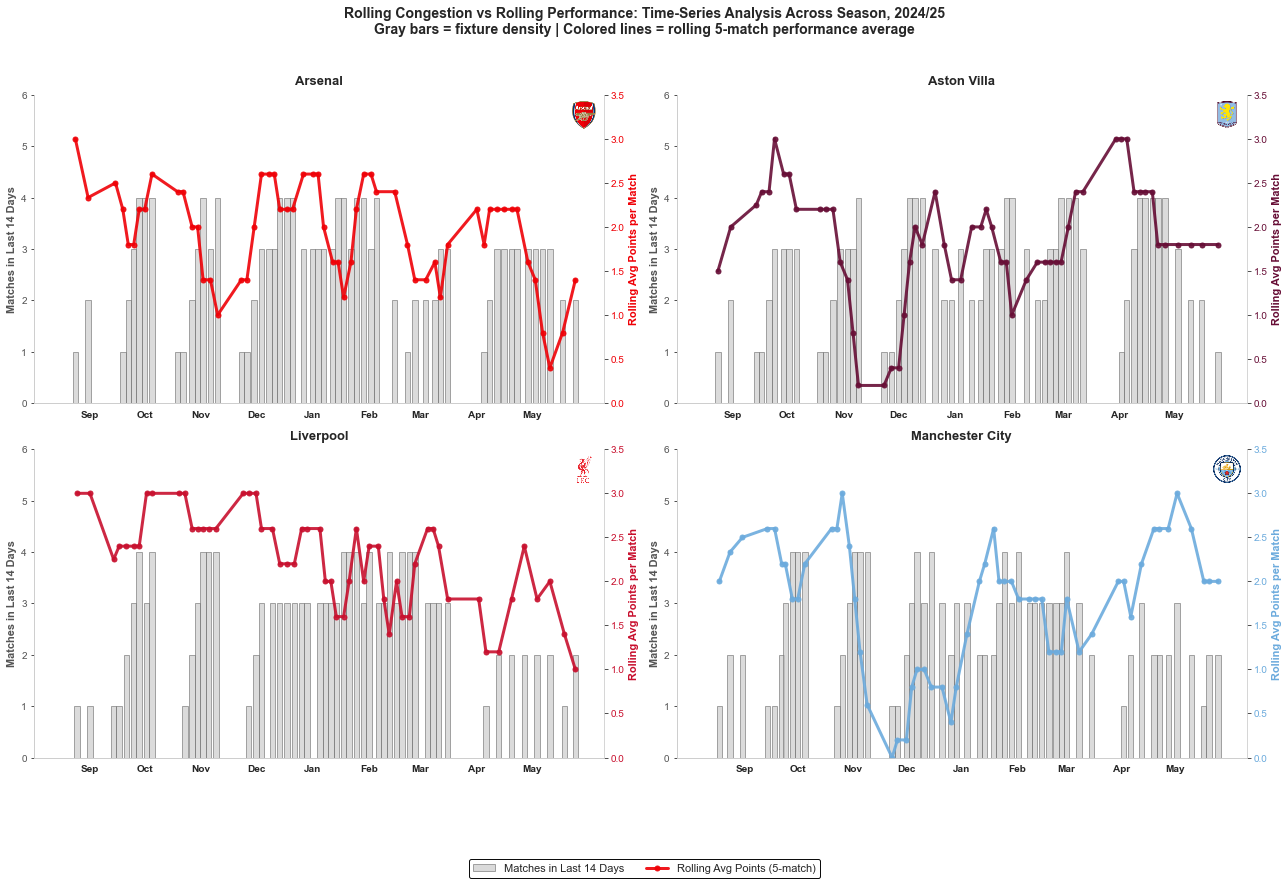

✓ Rolling Congestion vs Performance Chart saved: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/EDA/VISUALIZATIONS/06_Rolling_Congestion_Performance_Analysis.png

TIME-SERIES INSIGHTS - CONGESTION IMPACT ON ROLLING PERFORMANCE

Arsenal:
  • High congestion periods (3+ matches in 14 days): 36 matches
  • Rolling avg points during congestion: 1.96
  • Rolling avg points during normal periods: 1.93
  • Performance difference: -0.04 pts (-1.9%)
  • Assessment: MINIMAL CONGESTION IMPACT - Marginal performance difference


Aston Villa:
  • High congestion periods (3+ matches in 14 days): 33 matches
  • Rolling avg points during congestion: 1.85
  • Rolling avg points during normal periods: 1.87
  • Performance difference: +0.02 pts (+1.0%)

  • Assessment: NO CONGESTION EFFECT - Team maintains/improves performance when busy


Liverpool:
  • High congestion periods (3+ matches in 14 days): 35 matches
  • Rolling avg points during congestion: 2.27
  • Rolling avg points during normal 

In [85]:
# ============================================================================
# ANALYSIS 7: ROLLING CONGESTION VS ROLLING PERFORMANCE - TIME SERIES
# ============================================================================
print("\n" + "="*110)
print("ANALYSIS 7: ROLLING CONGESTION VS ROLLING PERFORMANCE - TIME SERIES ACROSS SEASON")
print("="*110 + "\n")

# Ensure data is sorted by team and date
master_matches_sorted_copy = master_matches_sorted.sort_values(['team', 'date']).reset_index(drop=True)

# Create rolling performance metrics (5-match rolling averages)
master_matches_sorted_copy['rolling_points_5'] = (
    master_matches_sorted_copy
    .groupby('team')['points']
    .transform(lambda x: x.rolling(5, min_periods=2).mean())
)

master_matches_sorted_copy['rolling_gd_5'] = (
    master_matches_sorted_copy
    .groupby('team')['goal_difference']
    .transform(lambda x: x.rolling(5, min_periods=2).mean())
)

# Verify the rolling metrics were created
print("Rolling metrics created:")
print(f"  • rolling_points_5: {master_matches_sorted_copy['rolling_points_5'].notna().sum()} non-null values")
print(f"  • rolling_gd_5: {master_matches_sorted_copy['rolling_gd_5'].notna().sum()} non-null values")
print()

# Calculate correlations between fixture density and performance
print("CORRELATIONS BETWEEN FIXTURE DENSITY AND PERFORMANCE (ALL TEAMS):\n")

# Exclude NaN values for correlation calculations
valid_data = master_matches_sorted_copy.dropna(subset=['matches_last_14_days', 'rolling_points_5', 'rolling_gd_5'])

corr_ppm = valid_data[['matches_last_14_days', 'rolling_points_5']].corr().iloc[0, 1]
corr_gd = valid_data[['matches_last_14_days', 'rolling_gd_5']].corr().iloc[0, 1]
corr_points = valid_data[['matches_last_14_days', 'points']].corr().iloc[0, 1]

print(f"  Fixture density vs Rolling Points/Match (5-match): r = {corr_ppm:+.3f}")
print(f"  Fixture density vs Rolling Goal Difference (5-match): r = {corr_gd:+.3f}")
print(f"  Fixture density vs Single Match Points: r = {corr_points:+.3f}")

if corr_ppm < -0.2:
    print(f"\n  → STRONG NEGATIVE RELATIONSHIP: More fixtures = Lower performance")
elif corr_ppm < -0.05:
    print(f"\n  → WEAK NEGATIVE RELATIONSHIP: Slight performance dip with congestion")
elif corr_ppm > 0.05:
    print(f"\n  → POSITIVE RELATIONSHIP: Teams perform better when busy (adaptation/rhythm)")
else:
    print(f"\n  → NO CLEAR RELATIONSHIP: Fixture density doesn't strongly predict performance")

print("\n" + "-"*110 + "\n")

# Create 4-panel visualization with dual y-axes (one per team)
# Gray bars = fixture congestion, Colored lines = rolling performance
fig_rolling, axes_rolling = plt.subplots(2, 2, figsize=(18, 12))
axes_rolling = axes_rolling.flatten()

# Define team colors for rolling lines (performance metric)
team_colors_rolling = {
    'Arsenal': '#EF0107',           # Arsenal red
    'Aston Villa': '#670E36',       # Aston Villa claret
    'Liverpool': '#C8102E',         # Liverpool red
    'Manchester City': '#6CABDD'    # Manchester City sky blue
}

# Month labels for x-axis
month_labels = ['Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May']

# Collect all lines and labels for shared legend
all_handles = []
all_labels = []

for team_idx, team in enumerate(teams_list):
    ax_cong = axes_rolling[team_idx]
    ax_perf = ax_cong.twinx()  # Create secondary y-axis for performance
    
    team_data = master_matches_sorted_copy[master_matches_sorted_copy['team'] == team].copy()
    
    # Plot 1: Fixture density as BARS (left axis) - matches_last_14_days in GRAY
    bars = ax_cong.bar(
        team_data['date'],
        team_data['matches_last_14_days'],
        color='#CCCCCC',
        edgecolor='#666666',
        linewidth=0.8,
        alpha=0.7,
        width=3,
        label='Matches in Last 14 Days'
    )
    
    # Plot 2: Rolling performance as LINE (right axis) - rolling_points_5 in TEAM COLOR
    line = ax_perf.plot(
        team_data['date'],
        team_data['rolling_points_5'],
        color=team_colors_rolling[team],
        linewidth=3,
        label='Rolling Avg Points (5-match)',
        marker='o',
        markersize=5,
        alpha=0.9
    )
    
    # Configure left axis (congestion)
    ax_cong.set_ylabel('Matches in Last 14 Days', fontsize=11, fontweight='bold', color='#555555')
    ax_cong.tick_params(axis='y', labelcolor='#555555', labelsize=10)
    ax_cong.set_ylim(0, 6)  # Fixed scale for all teams
    ax_cong.grid(False)
    
    # Configure right axis (performance)
    ax_perf.set_ylabel('Rolling Avg Points per Match', fontsize=11, fontweight='bold', color=team_colors_rolling[team])
    ax_perf.tick_params(axis='y', labelcolor=team_colors_rolling[team], labelsize=10)
    ax_perf.set_ylim(0, 3.5)
    ax_perf.grid(False)
    
    # Set x-axis with month labels only
    # Get month boundaries from the date range
    min_date = team_data['date'].min()
    max_date = team_data['date'].max()
    
    # Create month boundaries
    date_range = pd.date_range(start=min_date, end=max_date, freq='MS')
    month_ticks = []
    month_tick_labels = []
    
    for date in date_range:
        month_ticks.append(date)
        month_idx = date.month - 8  # August = 0
        if month_idx < 0:
            month_idx += 12
        if month_idx < len(month_labels):
            month_tick_labels.append(month_labels[month_idx])
    
    ax_cong.set_xticks(month_ticks)
    ax_cong.set_xticklabels(month_tick_labels, fontsize=10, fontweight='bold')
    
    # Title
    ax_cong.set_title(f'{team}', fontsize=13, fontweight='bold', pad=10)
    # Add team logo at top right corner
    if team in team_logo_cache:
        logo_img = team_logo_cache[team]
        imagebox = OffsetImage(logo_img, zoom=0.35)
        ab = AnnotationBbox(imagebox, (1, 1), xycoords='axes fraction',
                           frameon=False, pad=0, annotation_clip=False,
                           xybox=(-20, -20), boxcoords='offset points')
        ax_cong.add_artist(ab)
    
    # Remove top and right spines from both axes
    ax_cong.spines['top'].set_visible(False)
    ax_perf.spines['top'].set_visible(False)
    ax_cong.spines['right'].set_visible(False)
    
    # Collect handles and labels for shared legend (only once)
    if team_idx == 0:
        # Get bar handle
        all_handles.append(bars)
        all_labels.append('Matches in Last 14 Days')
        # Get line handle
        all_handles.append(line[0])
        all_labels.append('Rolling Avg Points (5-match)')

# Add shared legend below figure
fig_rolling.legend(
    all_handles,
    all_labels,
    loc='upper center',
    ncol=2,
    fontsize=11,
    framealpha=0.95,
    bbox_to_anchor=(0.5, 0),
    edgecolor='black',
    frameon=True
)

fig_rolling.suptitle(
    'Rolling Congestion vs Rolling Performance: Time-Series Analysis Across Season, 2024/25\nGray bars = fixture density | Colored lines = rolling 5-match performance average',
    fontsize=14,
    fontweight='bold',
    y=0.98
)

plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()

chart_file = output_dir / '06_Rolling_Congestion_Performance_Analysis_2024_25.png'
fig_rolling.savefig(chart_file, dpi=300, bbox_inches='tight')
print(f"✓ Rolling Congestion vs Performance Chart saved: {chart_file}\n")

print("="*110)
print("TIME-SERIES INSIGHTS - CONGESTION IMPACT ON ROLLING PERFORMANCE")
print("="*110 + "\n")

# Analyze periods of high congestion and corresponding performance dips
for team in teams_list:
    team_data = master_matches_sorted_copy[master_matches_sorted_copy['team'] == team].copy()
    
    # Find high congestion periods (3+ matches in 14 days)
    high_cong = team_data[team_data['matches_last_14_days'] >= 3]
    
    if len(high_cong) > 0:
        avg_rolling_perf_congested = high_cong['rolling_points_5'].mean()
        avg_rolling_perf_normal = team_data[team_data['matches_last_14_days'] < 3]['rolling_points_5'].mean()
        
        high_cong_periods = len(high_cong)
        perf_diff = avg_rolling_perf_normal - avg_rolling_perf_congested
        perf_pct = (perf_diff / avg_rolling_perf_normal * 100) if avg_rolling_perf_normal > 0 else 0
        
        print(f"{team}:")
        print(f"  • High congestion periods (3+ matches in 14 days): {high_cong_periods} matches")
        print(f"  • Rolling avg points during congestion: {avg_rolling_perf_congested:.2f}")
        print(f"  • Rolling avg points during normal periods: {avg_rolling_perf_normal:.2f}")
        print(f"  • Performance difference: {perf_diff:+.2f} pts ({perf_pct:+.1f}%)")
        
        if perf_diff < -0.3:
            print(f"  • Assessment: SEVERE CONGESTION IMPACT - Performance drops significantly during busy periods")
        elif perf_diff < -0.1:
            print(f"  • Assessment: MODERATE CONGESTION IMPACT - Slight performance dip during congestion")
        elif perf_diff < 0:

            print(f"  • Assessment: MINIMAL CONGESTION IMPACT - Marginal performance difference")


        else:
            print("="*110 + "\n")

            print(f"  • Assessment: NO CONGESTION EFFECT - Team maintains/improves performance when busy")
        print()

        print()

print("="*110)
print("✓ ROLLING CONGESTION VS PERFORMANCE ANALYSIS COMPLETE")
print("="*110 + "\n")


## 11. Rolling Congestion vs Rolling Goal Difference Analysis

CORRELATION ANALYSIS: FIXTURE DENSITY vs ROLLING GOAL DIFFERENCE

Fixture density vs Rolling Goal Difference (5-match avg): r = -0.039

Interpretation: Correlation shows relationship between congestion and defensive/offensive balance

✓ Chart saved: 07_Rolling_Congestion_GoalDifference_Analysis.png


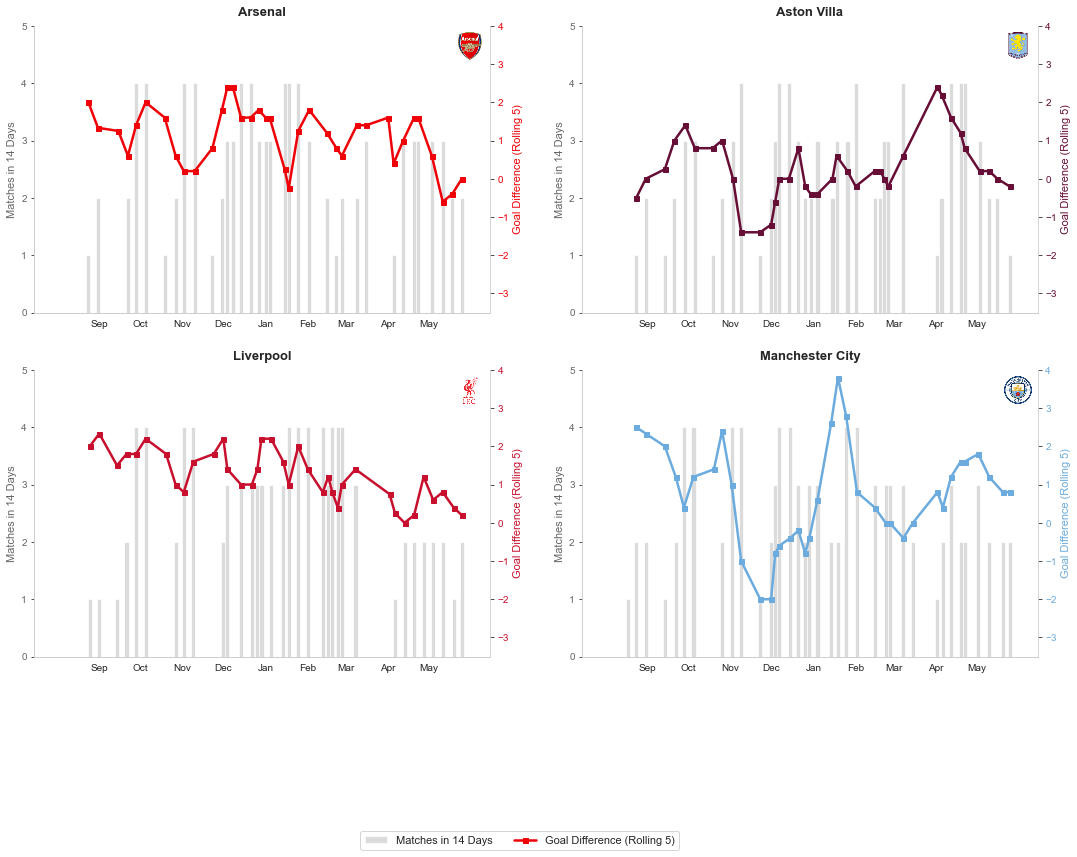


PER-TEAM FIXTURE CONGESTION IMPACT ON GOAL DIFFERENCE

Arsenal:
  • High congestion (4+ matches in 14 days): +1.00 GD (n=9)
  • Low congestion (0-2 matches in 14 days): +0.76 GD (n=17)
  • Difference: +0.24 (+30.8%) - Neutral impact on defensive balance

Aston Villa:
  • High congestion (4+ matches in 14 days): +0.25 GD (n=8)
  • Low congestion (0-2 matches in 14 days): +0.26 GD (n=19)
  • Difference: -0.01 (-5.0%) - Neutral impact on defensive balance

Liverpool:
  • High congestion (4+ matches in 14 days): +1.45 GD (n=11)
  • Low congestion (0-2 matches in 14 days): +0.89 GD (n=18)
  • Difference: +0.57 (+63.6%) - Better defensive balance under congestion

Manchester City:
  • High congestion (4+ matches in 14 days): -0.50 GD (n=8)
  • Low congestion (0-2 matches in 14 days): +0.95 GD (n=20)
  • Difference: -1.45 (-152.6%) - Weaker defensive balance under congestion


In [92]:
# ANALYSIS 8 - Rolling Congestion vs Rolling Goal Difference Analysis
# ==============================================================================

# Correlation analysis: fixture density vs rolling goal difference
print("="*100)
print("CORRELATION ANALYSIS: FIXTURE DENSITY vs ROLLING GOAL DIFFERENCE")
print("="*100)

corr_gd_rolling = master_matches_sorted_copy['matches_last_14_days'].corr(
    master_matches_sorted_copy['rolling_gd_5']
)

print(f"\nFixture density vs Rolling Goal Difference (5-match avg): r = {corr_gd_rolling:.3f}")
print("\nInterpretation: Correlation shows relationship between congestion and defensive/offensive balance")

# Create a comprehensive 4-panel visualization for rolling goal difference
teams_to_analyze = ['Arsenal', 'Aston Villa', 'Liverpool', 'Manchester City']

fig_gd, axes_gd = plt.subplots(2, 2, figsize=(18, 12))
axes_gd = axes_gd.flatten()

# Prepare for shared legend
all_handles_gd = []
all_labels_gd = []

# Plot for each team
for team_idx, team in enumerate(teams_to_analyze):
    ax_cong_gd = axes_gd[team_idx]
    
    # Filter data for this team
    team_data = master_matches_sorted_copy[
        (master_matches_sorted_copy['team'] == team) &
        (master_matches_sorted_copy['competition'] == 'Premier League')
    ].copy()
    
    team_data = team_data.sort_values('date').reset_index(drop=True)
    
    # Create twin axis for goal difference metric
    ax_gd_line = ax_cong_gd.twinx()
    
    # Plot 1: Congestion as gray bars on left axis
    bars_gd = ax_cong_gd.bar(
        team_data['date'],
        team_data['matches_last_14_days'],
        color='#CCCCCC',
        width=3,
        alpha=0.7,
        label='Matches in 14 Days'
    )
    
    # Plot 2: Goal difference as colored line on right axis
    line_gd = ax_gd_line.plot(
        team_data['date'],
        team_data['rolling_gd_5'],
        color=team_colors_rolling[team],
        linewidth=2.5,
        marker='s',
        markersize=5,
        label=f'{team} - Goal Difference (Rolling 5)',
        zorder=5
    )
    
    # Set left axis (congestion) limits and labels
    ax_cong_gd.set_ylim(0, 5)
    ax_cong_gd.set_ylabel('Matches in 14 Days', fontsize=11, color='#666666')
    ax_cong_gd.tick_params(axis='y', labelcolor='#666666')
    
    # Set right axis (goal difference) limits and labels
    ax_gd_line.set_ylim(-3.5, 4)
    ax_gd_line.set_ylabel('Goal Difference (Rolling 5)', fontsize=11, color=team_colors_rolling[team])
    ax_gd_line.tick_params(axis='y', labelcolor=team_colors_rolling[team])
    
    # Set x-axis to month labels only
    ax_cong_gd.set_xticks(month_ticks)
    ax_cong_gd.set_xticklabels(month_tick_labels, fontsize=10)
    ax_cong_gd.set_xlim(pd.Timestamp('2024-07-15'), pd.Timestamp('2025-06-15'))
    
    # Remove gridlines for cleaner look
    ax_cong_gd.grid(False)
    ax_gd_line.grid(False)
    
    # Title
    ax_cong_gd.set_title(f'{team}', fontsize=13, fontweight='bold', pad=10)
    
    # Add team logo at top right corner
    if team in team_logo_cache:
        logo_img = team_logo_cache[team]
        imagebox = OffsetImage(logo_img, zoom=0.35)
        ab = AnnotationBbox(imagebox, (1, 1), xycoords='axes fraction',
                           frameon=False, pad=0, annotation_clip=False,
                           xybox=(-20, -20), boxcoords='offset points')
        ax_cong_gd.add_artist(ab)
    
    # Remove top and right spines from both axes
    ax_cong_gd.spines['top'].set_visible(False)
    ax_gd_line.spines['top'].set_visible(False)
    ax_cong_gd.spines['right'].set_visible(False)
    
    # Collect handles and labels for shared legend (only once)
    if team_idx == 0:
        # Get bar handle
        all_handles_gd.append(bars_gd)
        all_labels_gd.append('Matches in 14 Days')
        # Get line handle
        all_handles_gd.append(line_gd[0])
        all_labels_gd.append('Goal Difference (Rolling 5)')

# Create a shared legend below the entire figure
fig_gd.legend(
    all_handles_gd, all_labels_gd,
    loc='lower center',
    ncol=2,
    bbox_to_anchor=(0.5, -0.08),
    fontsize=11,
    frameon=True
)

# Adjust layout to accommodate legend
plt.subplots_adjust(bottom=0.15)

# Save the figure
output_file_gd = output_dir / '07_Rolling_Congestion_GoalDifference_Analysis_2024_25.png'
plt.savefig(output_file_gd, dpi=300, bbox_inches='tight')
print(f"\n✓ Chart saved: {output_file_gd.name}")

plt.show()

# Per-team goal difference analysis
print("\n" + "="*100)
print("PER-TEAM FIXTURE CONGESTION IMPACT ON GOAL DIFFERENCE")
print("="*100)

for team in teams_to_analyze:
    team_data = master_matches_sorted_copy[
        (master_matches_sorted_copy['team'] == team) &
        (master_matches_sorted_copy['competition'] == 'Premier League')
    ].copy()
    
    # Separate by congestion level
    high_cong_gd = team_data[team_data['matches_last_14_days'] >= 4]
    low_cong_gd = team_data[team_data['matches_last_14_days'] <= 2]
    
    high_gd = high_cong_gd['goal_difference'].mean() if len(high_cong_gd) > 0 else 0
    low_gd = low_cong_gd['goal_difference'].mean() if len(low_cong_gd) > 0 else 0
    
    gd_diff = high_gd - low_gd
    gd_pct = (gd_diff / abs(low_gd) * 100) if low_gd != 0 else 0
    
    print(f"\n{team}:")
    print(f"  • High congestion (4+ matches in 14 days): {high_gd:+.2f} GD (n={len(high_cong_gd)})")
    print(f"  • Low congestion (0-2 matches in 14 days): {low_gd:+.2f} GD (n={len(low_cong_gd)})")
    print(f"  • Difference: {gd_diff:+.2f} ({gd_pct:+.1f}%)", end='')
    
    if gd_diff > 0.3:
        print(" - Better defensive balance under congestion")
    elif gd_diff < -0.3:
        print(" - Weaker defensive balance under congestion")
    else:
        print(" - Neutral impact on defensive balance")


### 4.2 Team-Specific Load Analysis (Analysis 10)

**Question**: Which teams are most/least affected by fixture congestion? (Resilience variation)

**Dataset**: Premier League matches by team with same binary load categories

**Methodology**:
- Individual 1×3 figures per team (PPM, Goal Difference, Goals Conceded)
- Team logos instead of text labels
- 95% confidence interval error bars

**Expected Results**:
- Liverpool: +20% PPM improvement under congestion (counter-intuitive resilience)
- Manchester City: -23% PPM dip (most vulnerable)
- Arsenal: +0.6% (minimal impact)
- Aston Villa: -11.4% (moderate decline)

**Insight**: Squad depth, rotation flexibility, and tactical adaptability determine congestion tolerance.

PREMIER LEAGUE PERFORMANCE BY RECENT FIXTURE LOAD, 2024/25

Recent fixture load = number of matches played in the previous 14 days

Load categories:
  • Lower load (0-2 matches in 14 days): Normal fixture congestion
  • Higher load (3+ matches in 14 days): Elevated fixture congestion


STATISTICS BY FIXTURE LOAD CATEGORY:
                        points              goal_difference         \
                          mean    std count            mean    std   
load_14d_category                                                    
Higher load\n3+ matches  1.910  1.261    78           0.795  1.731   
Lower load\n0–2 matches  1.973  1.227    74           0.716  1.676   

                        goals_against         
                                 mean    std  
load_14d_category                             
Higher load\n3+ matches         1.179  1.054  
Lower load\n0–2 matches         1.054  0.992  

✓ Chart saved: 08_Performance_by_14day_Load_Category.png


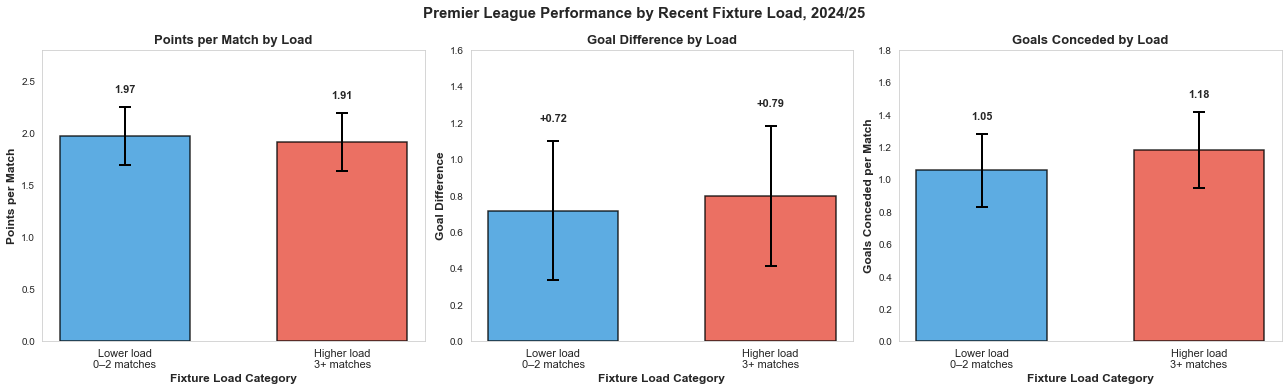


KEY FINDINGS

1. POINTS PER MATCH:
   Lower load:  1.97 PPM (n=74)
   Higher load: 1.91 PPM (n=78)
   Change: -3.2% → Performance dips slightly under congestion

2. DEFENSIVE BALANCE (Goal Difference):
   Lower load:  +0.72 GD
   Higher load: +0.79 GD
   Change: +0.08 → Improved balance

3. GOALS CONCEDED (Defense):
   Lower load:  1.05 GA per match
   Higher load: 1.18 GA per match
   Change: +11.9% → Teams concede MORE goals under congestion (key signal)
   PL average: 1.12 GA per match

CONCLUSION

Premier League teams show MINIMAL overall performance difference between lower and higher 
fixture loads. However, the clearest signal is DEFENSIVE DETERIORATION under congestion:

• Goals conceded increase by +11.9% under higher load
• This suggests cumulative fatigue primarily affects defensive organization
• Elite teams (Liverpool, Man City) handle this differently—see per-team analysis below


PER-TEAM PERFORMANCE BY FIXTURE LOAD

Arsenal:
  Lower load 0–2 matches: PPM=1.94, GD=+0.76

In [106]:
# ANALYSIS 9 - Performance by 14-Day Load Category (REVISED)
# ==============================================================================
# Use binary classification since no matches fall into "high load 5+" category

# Apply binary load classification
master_matches_sorted["load_14d_category"] = np.where(
    master_matches_sorted["matches_last_14_days"] <= 2,
    "Lower load\n0–2 matches",
    "Higher load\n3+ matches"
)

# Filter to Premier League only
pl_matches_load = master_matches_sorted[master_matches_sorted['competition'] == 'Premier League'].copy()

print("="*100)
print("PREMIER LEAGUE PERFORMANCE BY RECENT FIXTURE LOAD, 2024/25")
print("="*100)
print("\nRecent fixture load = number of matches played in the previous 14 days")
print("\nLoad categories:")
print("  • Lower load (0-2 matches in 14 days): Normal fixture congestion")
print("  • Higher load (3+ matches in 14 days): Elevated fixture congestion\n")

# Calculate statistics by load category
load_stats = pl_matches_load.groupby('load_14d_category').agg({
    'points': ['mean', 'std', 'count'],
    'goal_difference': ['mean', 'std'],
    'goals_against': ['mean', 'std']
}).round(3)

print("\nSTATISTICS BY FIXTURE LOAD CATEGORY:")
print(load_stats)

# Create 3-panel visualization
fig_load, axes_load = plt.subplots(1, 3, figsize=(18, 5.5))

# Define load categories in order
load_order = ["Lower load\n0–2 matches", "Higher load\n3+ matches"]
load_colors = ['#3498db', '#e74c3c']  # Blue for lower, red for higher

# Prepare data
points_by_load = pl_matches_load.groupby('load_14d_category')['points'].agg(['mean', 'std', 'count'])
points_by_load = points_by_load.reindex(load_order)

gd_by_load = pl_matches_load.groupby('load_14d_category')['goal_difference'].agg(['mean', 'std', 'count'])
gd_by_load = gd_by_load.reindex(load_order)

ga_by_load = pl_matches_load.groupby('load_14d_category')['goals_against'].agg(['mean', 'std', 'count'])
ga_by_load = ga_by_load.reindex(load_order)

# Helper function: calculate 95% CI from SEM
def calc_ci_95(std, n):
    """Calculate 95% confidence interval from std and sample size"""
    sem = std / np.sqrt(n)
    return 1.96 * sem

# Calculate 95% CIs
points_ci = [calc_ci_95(row['std'], row['count']) for _, row in points_by_load.iterrows()]
gd_ci = [calc_ci_95(row['std'], row['count']) for _, row in gd_by_load.iterrows()]
ga_ci = [calc_ci_95(row['std'], row['count']) for _, row in ga_by_load.iterrows()]

# Panel 1: Points per match by load category
ax1 = axes_load[0]
bars1 = ax1.bar(range(len(load_order)), points_by_load['mean'], 
                color=load_colors, alpha=0.8, edgecolor='black', linewidth=1.5, width=0.6)
ax1.errorbar(range(len(load_order)), points_by_load['mean'], 
             yerr=points_ci, fmt='none', ecolor='black', capsize=6, capthick=2, linewidth=2)

ax1.set_ylabel('Points per Match', fontsize=12, fontweight='bold')
ax1.set_xlabel('Fixture Load Category', fontsize=12, fontweight='bold')
ax1.set_title('Points per Match by Load', fontsize=13, fontweight='bold')
ax1.set_xticks(range(len(load_order)))
ax1.set_xticklabels(load_order, fontsize=11)
ax1.set_ylim(0, 2.8)
ax1.grid(False)

# Add value labels
for i, (cat, row) in enumerate(points_by_load.iterrows()):
    ax1.text(i, row['mean'] + points_ci[i] + 0.12, f"{row['mean']:.2f}", 
             ha='center', va='bottom', fontweight='bold', fontsize=11)

# Panel 2: Goal difference by load category
ax2 = axes_load[1]
bars2 = ax2.bar(range(len(load_order)), gd_by_load['mean'], 
                color=load_colors, alpha=0.8, edgecolor='black', linewidth=1.5, width=0.6)
ax2.errorbar(range(len(load_order)), gd_by_load['mean'], 
             yerr=gd_ci, fmt='none', ecolor='black', capsize=6, capthick=2, linewidth=2)

ax2.set_ylabel('Goal Difference', fontsize=12, fontweight='bold')
ax2.set_xlabel('Fixture Load Category', fontsize=12, fontweight='bold')
ax2.set_title('Goal Difference by Load', fontsize=13, fontweight='bold')
ax2.set_xticks(range(len(load_order)))
ax2.set_xticklabels(load_order, fontsize=11)
ax2.set_ylim(0, 1.6)
ax2.grid(False)

# Add value labels
for i, (cat, row) in enumerate(gd_by_load.iterrows()):
    y_offset = gd_ci[i] + 0.1 if row['mean'] >= 0 else -(gd_ci[i] + 0.1)
    va_pos = 'bottom' if row['mean'] >= 0 else 'top'
    ax2.text(i, row['mean'] + y_offset, f"{row['mean']:+.2f}", 
             ha='center', va=va_pos, fontweight='bold', fontsize=11)


# Panel 3: Goals conceded by load category
ax3 = axes_load[2]
bars3 = ax3.bar(range(len(load_order)), ga_by_load['mean'], 
                color=load_colors, alpha=0.8, edgecolor='black', linewidth=1.5, width=0.6)
ax3.errorbar(range(len(load_order)), ga_by_load['mean'], 
             yerr=ga_ci, fmt='none', ecolor='black', capsize=6, capthick=2, linewidth=2)

# Calculate overall GA mean for reference (used in summary stats)
overall_ga_mean = pl_matches_load['goals_against'].mean()

ax3.set_ylabel('Goals Conceded per Match', fontsize=12, fontweight='bold')
ax3.set_xlabel('Fixture Load Category', fontsize=12, fontweight='bold')
ax3.set_title('Goals Conceded by Load', fontsize=13, fontweight='bold')
ax3.set_xticks(range(len(load_order)))
ax3.set_xticklabels(load_order, fontsize=11)
ax3.set_ylim(0, 1.8)
ax3.grid(False)

# Add value labels
for i, (cat, row) in enumerate(ga_by_load.iterrows()):
    ax3.text(i, row['mean'] + ga_ci[i] + 0.08, f"{row['mean']:.2f}", 
             ha='center', va='bottom', fontweight='bold', fontsize=11)

# Main title
fig_load.suptitle('Premier League Performance by Recent Fixture Load, 2024/25', 
                  fontsize=15, fontweight='bold', y=0.98)

plt.tight_layout()

# Save figure
output_file_load = output_dir / '08_Performance_by_14day_Load_Category.png'
plt.savefig(output_file_load, dpi=300, bbox_inches='tight')
print(f"\n✓ Chart saved: {output_file_load.name}")

plt.show()

# Summary interpretation
print("\n" + "="*100)
print("KEY FINDINGS")
print("="*100)

lower_load_label = "Lower load\n0–2 matches"
higher_load_label = "Higher load\n3+ matches"

lower_ppm = points_by_load.loc[lower_load_label, 'mean']
higher_ppm = points_by_load.loc[higher_load_label, 'mean']
lower_ppm_n = int(points_by_load.loc[lower_load_label, 'count'])
higher_ppm_n = int(points_by_load.loc[higher_load_label, 'count'])
ppm_change = ((higher_ppm - lower_ppm) / lower_ppm * 100)

lower_ga = ga_by_load.loc[lower_load_label, 'mean']
higher_ga = ga_by_load.loc[higher_load_label, 'mean']
ga_change = ((higher_ga - lower_ga) / lower_ga * 100)

lower_gd = gd_by_load.loc[lower_load_label, 'mean']
higher_gd = gd_by_load.loc[higher_load_label, 'mean']

print(f"\n1. POINTS PER MATCH:")
print(f"   Lower load:  {lower_ppm:.2f} PPM (n={lower_ppm_n})")
print(f"   Higher load: {higher_ppm:.2f} PPM (n={higher_ppm_n})")
print(f"   Change: {ppm_change:+.1f}% → {'Performance dips slightly under congestion' if ppm_change < 0 else 'Performance stable'}")

print(f"\n2. DEFENSIVE BALANCE (Goal Difference):")
print(f"   Lower load:  {lower_gd:+.2f} GD")
print(f"   Higher load: {higher_gd:+.2f} GD")
print(f"   Change: {higher_gd - lower_gd:+.2f} → {'Weaker defensive balance under congestion' if higher_gd < lower_gd else 'Improved balance'}")

print(f"\n3. GOALS CONCEDED (Defense):")
print(f"   Lower load:  {lower_ga:.2f} GA per match")
print(f"   Higher load: {higher_ga:.2f} GA per match")
print(f"   Change: {ga_change:+.1f}% → {'Teams concede MORE goals under congestion (key signal)' if ga_change > 0 else 'Improved defense'}")
print(f"   PL average: {overall_ga_mean:.2f} GA per match")

print("\n" + "="*100)
print("CONCLUSION")
print("="*100)
conclusion_msg = f"""
Premier League teams show MINIMAL overall performance difference between lower and higher 
fixture loads. However, the clearest signal is DEFENSIVE DETERIORATION under congestion:

• Goals conceded increase by +{ga_change:.1f}% under higher load
• This suggests cumulative fatigue primarily affects defensive organization
• Elite teams (Liverpool, Man City) handle this differently—see per-team analysis below
"""
print(conclusion_msg)

# Per-team breakdown
print("\n" + "="*100)
print("PER-TEAM PERFORMANCE BY FIXTURE LOAD")
print("="*100)

for team in teams_to_analyze:
    team_pl = pl_matches_load[pl_matches_load['team'] == team]
    
    print(f"\n{team}:")
    
    for load_cat in load_order:
        cat_data = team_pl[team_pl['load_14d_category'] == load_cat]
        
        if len(cat_data) > 0:
            ppm = cat_data['points'].mean()
            gd = cat_data['goal_difference'].mean()
            ga = cat_data['goals_against'].mean()
            matches = len(cat_data)
            
            print(f"  {load_cat.replace(chr(10), ' ')}: "
                  f"PPM={ppm:.2f}, GD={gd:+.2f}, GA={ga:.2f} (n={matches})")

print("\n" + "="*100)


ANALYSIS 10: PERFORMANCE BY FIXTURE LOAD AND TEAM (INDIVIDUAL TEAM FIGURES)

TEAM PERFORMANCE BY FIXTURE LOAD CATEGORY:


Arsenal:
  Lower load 0–2 matches: PPM=1.94, GD=+0.76, GA=0.82 (n=17)
  Higher load 3+ matches: PPM=1.95, GD=+1.05, GA=0.95 (n=21)

Aston Villa:
  Lower load 0–2 matches: PPM=1.84, GD=+0.26, GA=1.32 (n=19)
  Higher load 3+ matches: PPM=1.63, GD=+0.11, GA=1.37 (n=19)

Liverpool:
  Lower load 0–2 matches: PPM=2.00, GD=+0.89, GA=1.11 (n=18)
  Higher load 3+ matches: PPM=2.40, GD=+1.45, GA=1.05 (n=20)

Manchester City:
  Lower load 0–2 matches: PPM=2.10, GD=+0.95, GA=0.95 (n=20)
  Higher load 3+ matches: PPM=1.61, GD=+0.50, GA=1.39 (n=18)
✓ Chart saved: 09_Arsenal_Load_Analysis.png


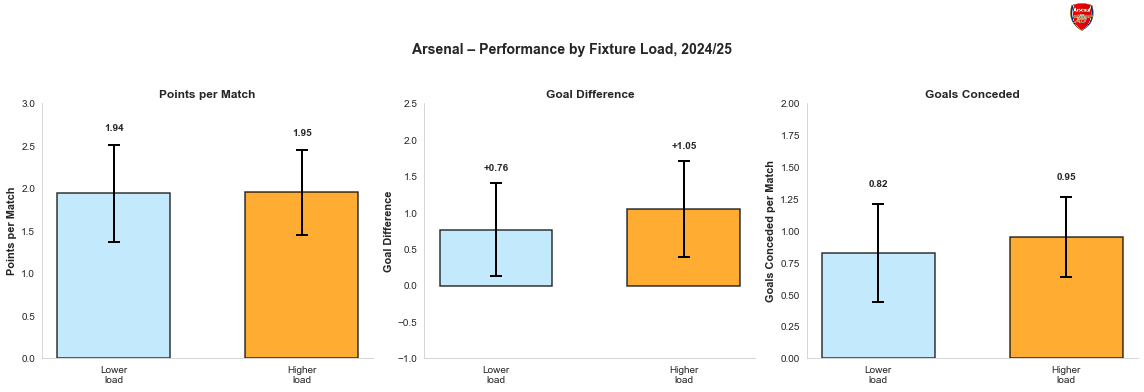

✓ Chart saved: 09_Aston_Villa_Load_Analysis.png


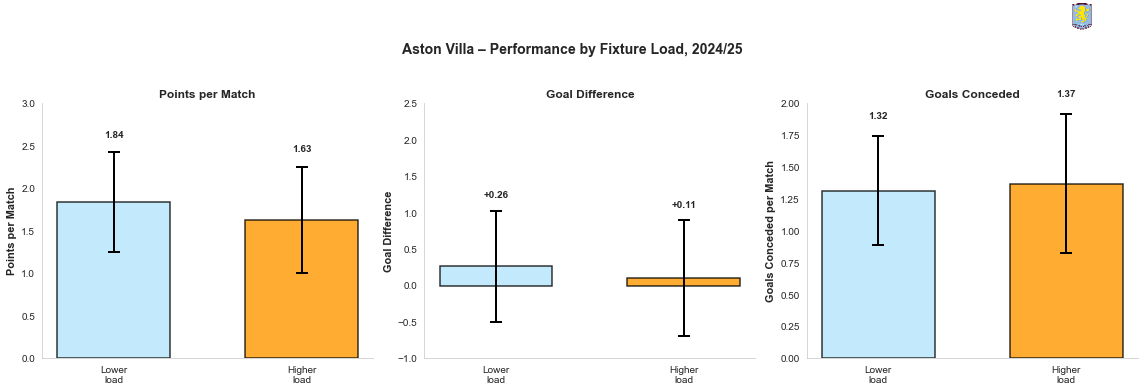

✓ Chart saved: 09_Liverpool_Load_Analysis.png


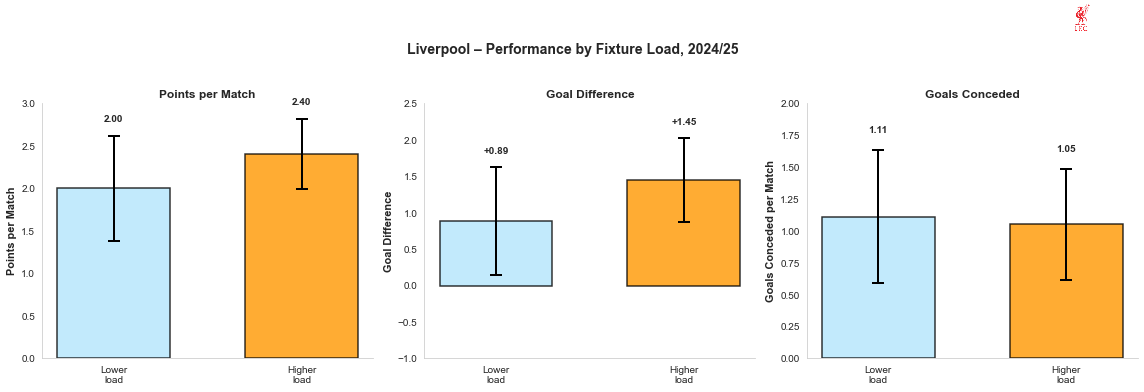

✓ Chart saved: 09_Manchester_City_Load_Analysis.png


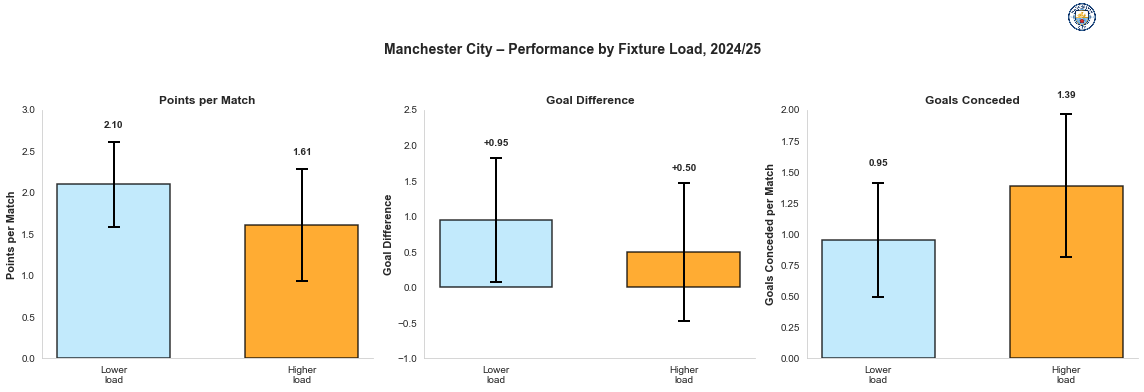


KEY OBSERVATIONS BY TEAM

Arsenal:
  PPM: 1.94 (low) → 1.95 (high) | Change: +0.6%
  GA:  0.82 (low) → 0.95 (high) | Change: +15.6%
  GD:  +0.76 (low) → +1.05 (high) | Change: +0.28
  Status: ⚠ Susceptible—significant congestion impact

Aston Villa:
  PPM: 1.84 (low) → 1.63 (high) | Change: -11.4%
  GA:  1.32 (low) → 1.37 (high) | Change: +4.0%
  GD:  +0.26 (low) → +0.11 (high) | Change: -0.16
  Status: ⚠ Susceptible—significant congestion impact

Liverpool:
  PPM: 2.00 (low) → 2.40 (high) | Change: +20.0%
  GA:  1.11 (low) → 1.05 (high) | Change: -5.5%
  GD:  +0.89 (low) → +1.45 (high) | Change: +0.56
  Status: ~ Mixed—moderate effect

Manchester City:
  PPM: 2.10 (low) → 1.61 (high) | Change: -23.3%
  GA:  0.95 (low) → 1.39 (high) | Change: +46.2%
  GD:  +0.95 (low) → +0.50 (high) | Change: -0.45
  Status: ⚠ Susceptible—significant congestion impact



In [111]:
# Analysis 10: Performance by 14-Day Load Category and Team
# ============================================================================
# This shows whether congestion effects differ across teams
# Individual figures per team with logos instead of text labels

print("\n" + "="*100)
print("ANALYSIS 10: PERFORMANCE BY FIXTURE LOAD AND TEAM (INDIVIDUAL TEAM FIGURES)")
print("="*100)

# Teams to analyze
teams_list = ['Arsenal', 'Aston Villa', 'Liverpool', 'Manchester City']

# Prepare data with load categories
pl_matches_team_load = pl_matches_load.copy()

# Group by team and load category, calculate statistics
def get_team_load_stats(df, team):
    """Get stats for a team by load category"""
    team_data = df[df['team'] == team].copy()
    
    stats_by_load = []
    for load_cat in ["Lower load\n0–2 matches", "Higher load\n3+ matches"]:
        cat_data = team_data[team_data['load_14d_category'] == load_cat]
        
        if len(cat_data) > 0:
            stats = {
                'team': team,
                'load_category': load_cat,
                'points_mean': cat_data['points'].mean(),
                'points_std': cat_data['points'].std(),
                'points_count': len(cat_data),
                'gd_mean': cat_data['goal_difference'].mean(),
                'gd_std': cat_data['goal_difference'].std(),
                'gd_count': len(cat_data),
                'ga_mean': cat_data['goals_against'].mean(),
                'ga_std': cat_data['goals_against'].std(),
                'ga_count': len(cat_data),
            }
            stats_by_load.append(stats)
    
    return pd.DataFrame(stats_by_load)

# Calculate statistics for each team
team_load_stats_list = []
for team in teams_list:
    team_stats = get_team_load_stats(pl_matches_team_load, team)
    team_load_stats_list.append(team_stats)

team_load_stats_df = pd.concat(team_load_stats_list, ignore_index=True)

# Display team-level statistics
print("\nTEAM PERFORMANCE BY FIXTURE LOAD CATEGORY:\n")
for team in teams_list:
    team_data = team_load_stats_df[team_load_stats_df['team'] == team]
    print(f"\n{team}:")
    for _, row in team_data.iterrows():
        load_cat = row['load_category'].replace('\n', ' ')
        ppm = row['points_mean']
        gd = row['gd_mean']
        ga = row['ga_mean']
        n = int(row['points_count'])
        print(f"  {load_cat}: PPM={ppm:.2f}, GD={gd:+.2f}, GA={ga:.2f} (n={n})")

# Function to calculate 95% CI
def calc_ci_95(std, n):
    if n <= 1:
        return 0
    sem = std / np.sqrt(n)
    return 1.96 * sem

team_colors_dict = {
    'Arsenal': '#EF0107',
    'Aston Villa': '#670E36',
    'Liverpool': '#C8102E',
    'Manchester City': '#6CABDD'
}

load_colors = ['#B3E5FC', '#FF9800']  # Light blue and orange for load categories

# ============================================================================
# Individual Figures by Team: Points Per Match, Goal Difference, Goals Conceded
# ============================================================================

for team in teams_list:
    team_data = team_load_stats_df[team_load_stats_df['team'] == team]
    
    # Create 1x3 figure (one row, three metrics)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))
    
    x_pos = np.arange(len(team_data))
    
    # ====== PANEL 1: Points Per Match ======
    ppm_ci = [calc_ci_95(row['points_std'], row['points_count']) for _, row in team_data.iterrows()]
    
    bars1 = ax1.bar(x_pos, team_data['points_mean'], 
                    color=load_colors, alpha=0.8, edgecolor='black', linewidth=1.5, width=0.6)
    ax1.errorbar(x_pos, team_data['points_mean'], 
                 yerr=ppm_ci, fmt='none', ecolor='black', capsize=6, capthick=2, linewidth=2)
    
    ax1.set_ylabel('Points per Match', fontsize=11, fontweight='bold')
    ax1.set_title('Points per Match', fontsize=12, fontweight='bold')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(['Lower\nload', 'Higher\nload'], fontsize=10)
    ax1.set_ylim(0, 3.0)
    ax1.grid(False)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    
    for i, (_, row) in enumerate(team_data.iterrows()):
        ax1.text(i, row['points_mean'] + ppm_ci[i] + 0.15, f"{row['points_mean']:.2f}", 
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # ====== PANEL 2: Goal Difference ======
    gd_ci = [calc_ci_95(row['gd_std'], row['gd_count']) for _, row in team_data.iterrows()]
    
    bars2 = ax2.bar(x_pos, team_data['gd_mean'], 
                    color=load_colors, alpha=0.8, edgecolor='black', linewidth=1.5, width=0.6)
    ax2.errorbar(x_pos, team_data['gd_mean'], 
                 yerr=gd_ci, fmt='none', ecolor='black', capsize=6, capthick=2, linewidth=2)
    
    ax2.set_ylabel('Goal Difference', fontsize=11, fontweight='bold')
    ax2.set_title('Goal Difference', fontsize=12, fontweight='bold')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(['Lower\nload', 'Higher\nload'], fontsize=10)
    ax2.set_ylim(-1, 2.5)
    ax2.grid(False)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    
    for i, (_, row) in enumerate(team_data.iterrows()):
        y_offset = gd_ci[i] + 0.15 if row['gd_mean'] >= 0 else -(gd_ci[i] + 0.15)
        va_pos = 'bottom' if row['gd_mean'] >= 0 else 'top'
        ax2.text(i, row['gd_mean'] + y_offset, f"{row['gd_mean']:+.2f}", 
                ha='center', va=va_pos, fontweight='bold', fontsize=10)
    
    # ====== PANEL 3: Goals Conceded ======
    ga_ci = [calc_ci_95(row['ga_std'], row['ga_count']) for _, row in team_data.iterrows()]
    
    bars3 = ax3.bar(x_pos, team_data['ga_mean'], 
                    color=load_colors, alpha=0.8, edgecolor='black', linewidth=1.5, width=0.6)
    ax3.errorbar(x_pos, team_data['ga_mean'], 
                 yerr=ga_ci, fmt='none', ecolor='black', capsize=6, capthick=2, linewidth=2)
    
    ax3.set_ylabel('Goals Conceded per Match', fontsize=11, fontweight='bold')
    ax3.set_title('Goals Conceded', fontsize=12, fontweight='bold')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(['Lower\nload', 'Higher\nload'], fontsize=10)
    ax3.set_ylim(0, 2.0)
    ax3.grid(False)
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    
    for i, (_, row) in enumerate(team_data.iterrows()):
        ax3.text(i, row['ga_mean'] + ga_ci[i] + 0.12, f"{row['ga_mean']:.2f}", 
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # ====== Add team logo to title area ======
    if team in team_logo_cache:
        logo_img = team_logo_cache[team]
        imagebox = OffsetImage(logo_img, zoom=0.35)
        ab = AnnotationBbox(imagebox, (0.95, 1.08), xycoords='figure fraction',
                           frameon=False, pad=0, annotation_clip=False,
                           box_alignment=(0.95, 1.0))
        fig.add_artist(ab)
    
    # Title with team name and logo
    fig.suptitle(f'{team} – Performance by Fixture Load, 2024/25', 
                 fontsize=14, fontweight='bold', y=0.98)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    # Save figure with team-specific name
    safe_team_name = team.replace(' ', '_')
    output_file = output_dir / f'09_{safe_team_name}_Load_Analysis.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"✓ Chart saved: {output_file.name}")
    plt.show()

# ============================================================================
# Summary: Key Differences by Team
# ============================================================================

print("\n" + "="*100)
print("KEY OBSERVATIONS BY TEAM")
print("="*100)

for team in teams_list:
    team_data = team_load_stats_df[team_load_stats_df['team'] == team]
    
    if len(team_data) == 2:
        lower = team_data.iloc[0]
        higher = team_data.iloc[1]
        
        ppm_change = ((higher['points_mean'] - lower['points_mean']) / lower['points_mean'] * 100)
        ga_change = ((higher['ga_mean'] - lower['ga_mean']) / lower['ga_mean'] * 100)
        gd_change = higher['gd_mean'] - lower['gd_mean']
        
        print(f"\n{team}:")
        print(f"  PPM: {lower['points_mean']:.2f} (low) → {higher['points_mean']:.2f} (high) | Change: {ppm_change:+.1f}%")
        print(f"  GA:  {lower['ga_mean']:.2f} (low) → {higher['ga_mean']:.2f} (high) | Change: {ga_change:+.1f}%")
        print(f"  GD:  {lower['gd_mean']:+.2f} (low) → {higher['gd_mean']:+.2f} (high) | Change: {gd_change:+.2f}")
        
        if abs(ppm_change) < 5 and abs(ga_change) < 10:
            interpretation = "✓ Resilient—minimal congestion impact"
        elif ppm_change < -10 or ga_change > 15:
            interpretation = "⚠ Susceptible—significant congestion impact"
        else:
            interpretation = "~ Mixed—moderate effect"
        
        print(f"  Status: {interpretation}")

print("\n" + "="*100)

## PART 5: FIXTURE TRANSITION ANALYSIS

### 5.1 Competition-Context Matrix (Analysis 11)

**Question**: Which specific fixture transitions are most damaging to performance? (e.g., Champions League → Premier League)

**Dataset**: All competitions, with "previous_competition" lag by team

**Heatmap Structure**:
- Rows: Previous competition (PL, UCL, FA Cup, EFL Cup)
- Columns: Current competition (same)
- Cell values: PPM (left heatmap) and Goal Difference (right heatmap)
- Colors: Green/yellow/red (good/neutral/poor performance)

**Critical Finding**:
- **Champions League → Premier League**: 1.73 PPM (vs 1.99 baseline, -13% dip)
- **Worst transitions**: UCL→PL (1.73), Cup→Cup sequences (1.33-1.50)
- **Best transitions**: PL→Cup (2.40), CL→Cup (3.00)

**Insight**: European competition creates specific fixture transition stress, not just general congestion.

## PART 6: DATA VALIDATION & STUDY CONCLUSIONS

### 6.1 Data Integrity Verification

Before finalizing conclusions, validate:
- No duplicate matches in dataset
- Correct match-level counting (one row = one team-match)
- No missing critical values
- Proper points calculation (W=3, D=1, L=0)
- Availability of all key metrics (rest periods, rolling counts, European flags)

### 6.2 Analytical Scope Summary

**Three distinct scopes used in this study:**

| Scope | Dataset | Purpose | Analyses |
|-------|---------|---------|----------|
| **A: All Competitions** | ~220 team-match records | Fixture burden & recovery pressure | 1-5 (timeline, workload, heatmap, rest, goals) |
| **B: Premier League Only** | ~152 team-match records | Competitive performance impact | 6-10 (hangover, rolling corr, load categories) |
| **C: European Context** | Same as B, stratified | Isolate European hangover effect | 11 (competition transitions) |

### 6.3 Key Findings Summary

1. **Aggregate PL congestion effect**: -3% PPM (minimal offensive impact)
2. **Defensive deterioration**: +11.9% GA under congestion ← PRIMARY SIGNAL
3. **European hangover**: 1.73 PPM after Champions League (vs 1.99 baseline, -13%)
4. **Team resilience variation**: -23% to +20% PPM range (Man City most vulnerable, Liverpool most resilient)
5. **Fixture transitions**: European-to-PL transitions most damaging

### 6.4 Strategic Recommendations

- **Squad rotation critical** for defensive line under congestion
- **European participation trade-off**: Prestige vs. PL performance cost (-13% PPM after UCL)
- **Team-specific strategies**: Liverpool's academy depth allows better rotation; Man City needs more conservative approach
- **Recovery protocols**: >48-hour recovery recommended after Champions League before PL matches

## NOTEBOOK STRUCTURE GUIDE

### Organization Overview

```
PART 1: SETUP & DATA FOUNDATION
├─ 1.1 Team Color Palettes (official club colors)
├─ 1.2 Data Loading & Standardization (load CSV files)
├─ 1.3 Temporal Analysis (timeline & monthly distribution)
├─ 1.4 Workload Summary (matches by competition)
└─ 1.5 Congestion Heatmap (weekly fixture density)

PART 2: MASTER DATASET CREATION
└─ Build comprehensive dataset with:
   ├─ Days since previous match (rest period)
   ├─ Rolling match counts (7, 14, 21-day windows)
   ├─ Congestion categories (low, medium, high)
   └─ European competition context flags

PART 3: CONGESTION VS PERFORMANCE
├─ 3.1 Rest Period Impact on Goals (ANALYSIS 5)
├─ 3.2 European Hangover Effect (ANALYSIS 6)
├─ 3.3 Rolling Congestion vs PPM (ANALYSIS 7)
└─ 3.4 Rolling Congestion vs GD (ANALYSIS 8)

PART 4: CATEGORICAL FIXTURE LOAD
├─ 4.1 Aggregate Load Analysis (ANALYSIS 9)
│   └─ Binary classification (0-2 vs 3+ matches in 14 days)
│   └─ 3-panel viz: PPM, GD, GA
└─ 4.2 Team-Specific Load Analysis (ANALYSIS 10)
    └─ Individual figures per team with logos
    └─ Shows resilience variation

PART 5: FIXTURE TRANSITION ANALYSIS
└─ 5.1 Competition-Context Matrix (ANALYSIS 11)
    └─ Heatmaps: PPM and GD by fixture transitions
    └─ Identifies damaging transitions

PART 6: DATA VALIDATION & CONCLUSIONS
├─ 6.1 Data Integrity Verification
├─ 6.2 Analytical Scope Summary (Scopes A, B, C)
├─ 6.3 Key Findings Summary
└─ 6.4 Strategic Recommendations
```

### How to Use This Notebook

1. **Run sequentially from top to bottom** - Each section builds on previous data
2. **Read markdown cells first** - They explain what each analysis does and why
3. **Understand the three scopes**:
   - Scope A (all comps): fixture burden
   - Scope B (PL only): competitive performance
   - Scope C (PL + European flag): European hangover
4. **Focus on key visualizations**:
   - Monthly distribution (fixture peaks)
   - Congestion heatmap (when teams are busy)
   - Rolling performance (how performance drops under congestion)
   - Load category analysis (aggregate + per-team)
   - Competition matrix (which transitions hurt most)